# 03 — Data Visualisation Suite

**Dissertation:** *Agentic AI for Sovereign Risk Assessment under Climate-Related Fiscal Stress*

This notebook produces all publication-quality figures and summary tables for  
Chapter 3 (Data Description) and Chapter 4 (Results) of the dissertation.

**RL context recap:** DQN and PPO agents train across a 3×3 matrix:  
3 economy types (Advanced, Emerging Market, Developing) × 3 climate risk tiers (Low, Medium, High).  
The 7-variable state space is: output growth, debt-to-GDP, primary balance, interest rate,  
climate shock indicator, adaptation capital, and risk premium.

**Output directory:** `outputs/figures/`  
**Naming convention:** `fig_XX_description.png` / `.svg` and `table_XX_description.csv`

---
| Figure | Title | Chapter |
|--------|-------|---------|
| 01 | Country Coverage World Map | 3 |
| 02 | Temporal Coverage Heatmap | 3 |
| 03 | Missingness Profile | 3 (Methodology) |
| 04 | Sample Size by Economy Type and Decade | 3 |
| 05 | State Variable Distributions | 3 |
| 06 | Box Plots of State Variables | 3 |
| 07 | Correlation Heatmap | 3 |
| 08 | Debt-to-GDP Trends | 3/4 |
| 09 | Climate Damage Trends | 3/4 |
| 10 | Climate Damage vs. Debt Change | 4 (Core) |
| 11 | Vulnerability vs. Fiscal Space | 4 |
| 12 | Adaptation Readiness vs. Debt | 4 |
| 13 | Experimental Matrix Balance | 3 |
| 14 | Debt Source Comparison | Appendix |
| 15 | GDP Growth Source Comparison | Appendix |
| Table 1 | Descriptive Statistics | 3 |

---
## Setup — packages, paths, style

We install any missing packages, set a globally consistent visual style, and define  
the colour palette for economy types. Every subsequent figure imports these definitions  
so the dissertation looks visually coherent throughout.

In [3]:
%pip install seaborn geopandas geodatasets 
%pip install matoplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matoplotlib (from versions: none)
ERROR: No matching distribution found for matoplotlib


In [4]:
import sys
import warnings
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
def find_project_root(start: Path = Path().resolve()) -> Path:
    for directory in [start, *start.parents]:
        if (directory / "config").is_dir():
            return directory
    raise FileNotFoundError("Cannot find project root — expected a config/ folder.")

PROJECT_ROOT = find_project_root()
MASTER_FILE  = PROJECT_ROOT / "data" / "processed" / "master_panel.csv"
FIG_DIR      = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Global visual style ───────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.2)
matplotlib.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Economy type colours (Set2 — colourblind-friendly) ────────────────────────
# Set2 order: green, orange, blue, pink, brown, yellow, grey, black
_set2 = sns.color_palette("Set2", 8)
ECON_COLORS = {
    "Advanced":       _set2[1],   # orange
    "Emerging Market":_set2[0],   # green
    "Developing":     _set2[2],   # blue
}
ECON_ORDER = ["Advanced", "Emerging Market", "Developing"]

# ── Source colours for missingness figure ────────────────────────────────────
SOURCE_COLORS = {
    "WEO":     _set2[1],
    "WDI":     _set2[0],
    "IMF Debt":_set2[3],
    "ND-GAIN": _set2[2],
    "EM-DAT":  _set2[4],
    "Consolidated": _set2[6],
}

# ── Figure tracking ───────────────────────────────────────────────────────────
SAVED_FILES = []

def save_fig(fig, stem: str):
    """Save figure as both PNG (300 dpi) and SVG; record filenames."""
    for ext in (".png", ".svg"):
        p = FIG_DIR / (stem + ext)
        fig.savefig(p, dpi=300, bbox_inches="tight")
        SAVED_FILES.append(p.name)
    print(f"  Saved: {stem}.png  |  {stem}.svg  →  {FIG_DIR}")

print(f"Project root : {PROJECT_ROOT}")
print(f"Figure output: {FIG_DIR}")
print(f"Matplotlib   : {matplotlib.__version__}")
print(f"Seaborn      : {sns.__version__}")

Project root : C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent
Figure output: C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures
Matplotlib   : 3.10.8
Seaborn      : 0.13.2


---
## Load and validate master panel

In [5]:
df = pd.read_csv(MASTER_FILE)

print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns       : {df.columns.tolist()}")
print(f"Year range    : {df['year'].min()} – {df['year'].max()}")
print(f"Countries     : {df['iso3'].nunique()}")
print(f"Economy types : {df['economy_type'].value_counts(dropna=False).to_dict()}")

# Working subset: 1990–2024 only (drops WEO projections beyond 2024 and pre-1990 data)
df_analysis = df[(df["year"] >= 1990) & (df["year"] <= 2024)].copy()
print(f"\nAnalysis subset (1990–2024): {df_analysis.shape[0]:,} rows, {df_analysis['iso3'].nunique()} countries")

# Convenience: GDP in billions USD, damage in '000 USD
# damage % of GDP = (damage_adj_000usd * 1000) / (gdp_current_bn * 1e9) * 100
#                 = damage_adj_000usd / (gdp_current_bn * 1e4)
df_analysis["climate_damage_pct_gdp"] = (
    df_analysis["climate_damage_adj_000usd"] / (df_analysis["weo_gdp_current"] * 1e4)
)

# Year-on-year change in debt-to-GDP (within each country)
df_analysis = df_analysis.sort_values(["iso3", "year"])
df_analysis["debt_change"] = df_analysis.groupby("iso3")["debt_to_gdp"].diff()

print("Derived columns added: climate_damage_pct_gdp, debt_change")

Shape         : 9,059 rows × 51 columns
Columns       : ['iso3', 'year', 'weo_gdp_constant', 'weo_gdp_current', 'weo_gdp_per_capita', 'weo_gdp_deflator', 'weo_govt_gross_debt', 'weo_primary_balance', 'weo_govt_revenue', 'weo_govt_expenditure', 'weo_fiscal_balance', 'weo_structural_balance', 'weo_output_gap', 'weo_current_account', 'weo_inflation_cpi', 'weo_population', 'weo_unemployment', 'imf_cg_debt_to_gdp', 'wdi_gdp_current_usd', 'wdi_gdp_growth', 'wdi_debt_to_gdp', 'wdi_tax_revenue_gdp', 'wdi_gov_expenditure_gdp', 'wdi_inflation_cpi', 'wdi_inflation_deflator', 'wdi_current_account_gdp', 'climate_disaster_count', 'climate_damage_000usd', 'climate_damage_adj_000usd', 'ndgain_score', 'ndgain_readiness', 'ndgain_vulnerability', 'ndgain_exposure', 'ndgain_sensitivity', 'ndgain_capacity', 'country_name', 'Income group', 'Lending category', 'economy_type', 'inform_risk', 'inform_natural_hazard', 'inform_drought', 'inform_river_flood', 'inform_tropical_cyclone', 'inform_coastal_flood', 'in

---
## Figure 1 — Country Coverage World Map

**What it shows:** A choropleth map of the 196 countries in the master panel, colour-coded  
by economy type (Advanced, Emerging Market, Developing). Countries not in the dataset  
appear in light grey.

**Why it matters:** The examiner needs to see the geographic scope and distribution across  
economy types at a glance. A world map is the most intuitive way to establish that the  
dataset has genuine global coverage and is not biased toward a particular region.

**Chapter:** 3 — Data Description (opening figure)

Countries with economy_type classification: 192


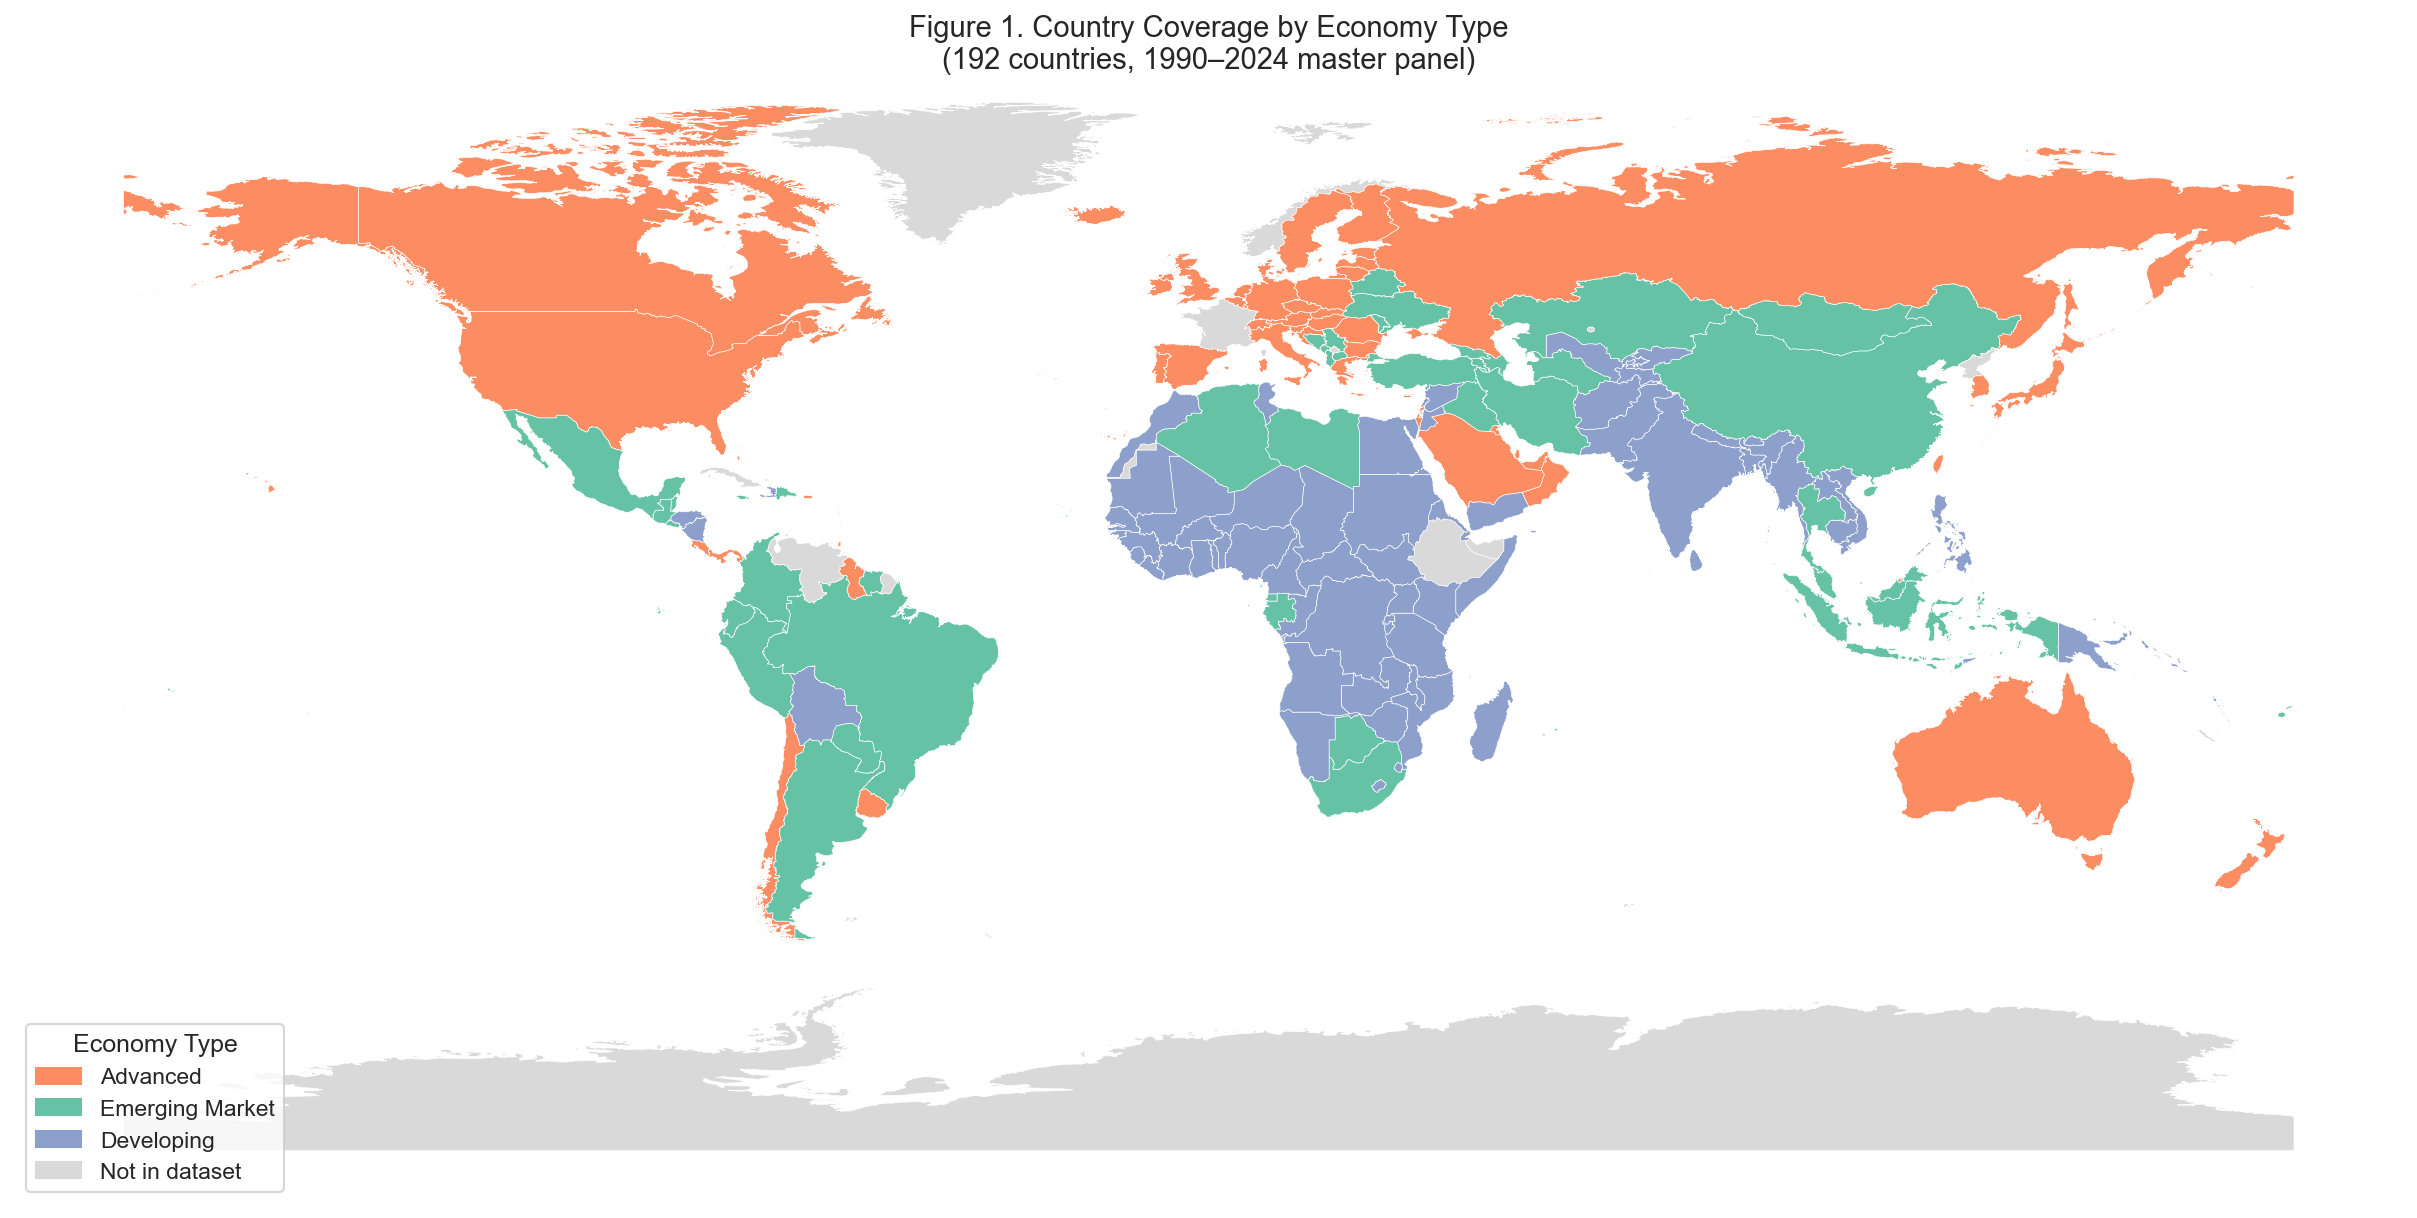

  Saved: fig_01_country_coverage_map.png  |  fig_01_country_coverage_map.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [ ]:
try:
    import geopandas as gpd

    # Load world boundaries via a public GeoJSON (geopandas ≥1.0 removed built-in datasets)
    COUNTRIES_URL = (
        "https://raw.githubusercontent.com/datasets/geo-countries/"
        "master/data/countries.geojson"
    )

    world = gpd.read_file(COUNTRIES_URL)
    # ISO column in this source is 'ISO3166-1-Alpha-3'
    world = world.rename(columns={"ISO3166-1-Alpha-3": "iso3"})

    # Get one classification row per country from the analysis panel
    country_class = (
        df_analysis[["iso3", "economy_type"]]
        .dropna(subset=["economy_type"])
        .drop_duplicates("iso3")
    )
    
    print(f"Countries with economy_type classification: {len(country_class)}")

    # Merge classification onto world shapefile
    world_merged = world.merge(country_class, on="iso3", how="left")

    # Build colour column
    color_map = {**ECON_COLORS, "__missing__": "#d9d9d9"}
    world_merged["color"] = world_merged["economy_type"].map(ECON_COLORS).fillna("#d9d9d9")

    fig, ax = plt.subplots(figsize=(16, 8), constrained_layout=True)

    world_merged.plot(
        color=world_merged["color"],
        linewidth=0.3,
        edgecolor="white",
        ax=ax,
    )

    # Legend
    legend_patches = [
        mpatches.Patch(color=ECON_COLORS[et], label=et) for et in ECON_ORDER
    ] + [mpatches.Patch(color="#d9d9d9", label="Not in dataset")]
    ax.legend(handles=legend_patches, loc="lower left", frameon=True, fontsize=11,
              title="Economy Type", title_fontsize=12)

    ax.set_axis_off()
    n_in = country_class['iso3'].nunique()
    fig.suptitle(
        f"Figure 1. Country Coverage by Economy Type\n"
        f"({n_in} countries, 1990–2024 master panel)",
        fontsize=14, y=1.01
    )

    plt.show()
    save_fig(fig, "fig_01_country_coverage_map")
    plt.close(fig)

except Exception:
    print("Figure 1 FAILED — error:")
    traceback.print_exc()

---
## Figure 2 — Panel Balance and Temporal Coverage Heatmap

**What it shows:** A heatmap where each cell shows how many of the 7 core state-space  
variables are non-missing for a given country-year. Darker cells = more complete data.  
Countries are grouped by economy type; years run 1990–2024 on the x-axis.

**Why it matters:** Justifies any temporal restrictions in the RL training window (e.g.,  
starting from 1995 if ND-GAIN data is unavailable before then). Also shows whether  
specific country-years have insufficient state information to construct valid RL episodes.

To keep the chart legible, we show the 10 largest economies (by mean GDP) from each  
economy type, ~30 countries total. This is noted in the figure caption.

**Chapter:** 3 — Data Description (data quality subsection)

Representative sample: 30 countries
  Advanced: ['KOR', 'JPN', 'CHL', 'RUS', 'HUN', 'CRI', 'USA', 'TWN', 'CZE', 'SWE']
  Emerging Market: ['IRN', 'IDN', 'COL', 'IRQ', 'PRY', 'CHN', 'KAZ', 'ARG', 'MNG', 'MEX']
  Developing: ['VNM', 'UZB', 'LBN', 'IND', 'LAO', 'NGA', 'KHM', 'UGA', 'TZA', 'MMR']


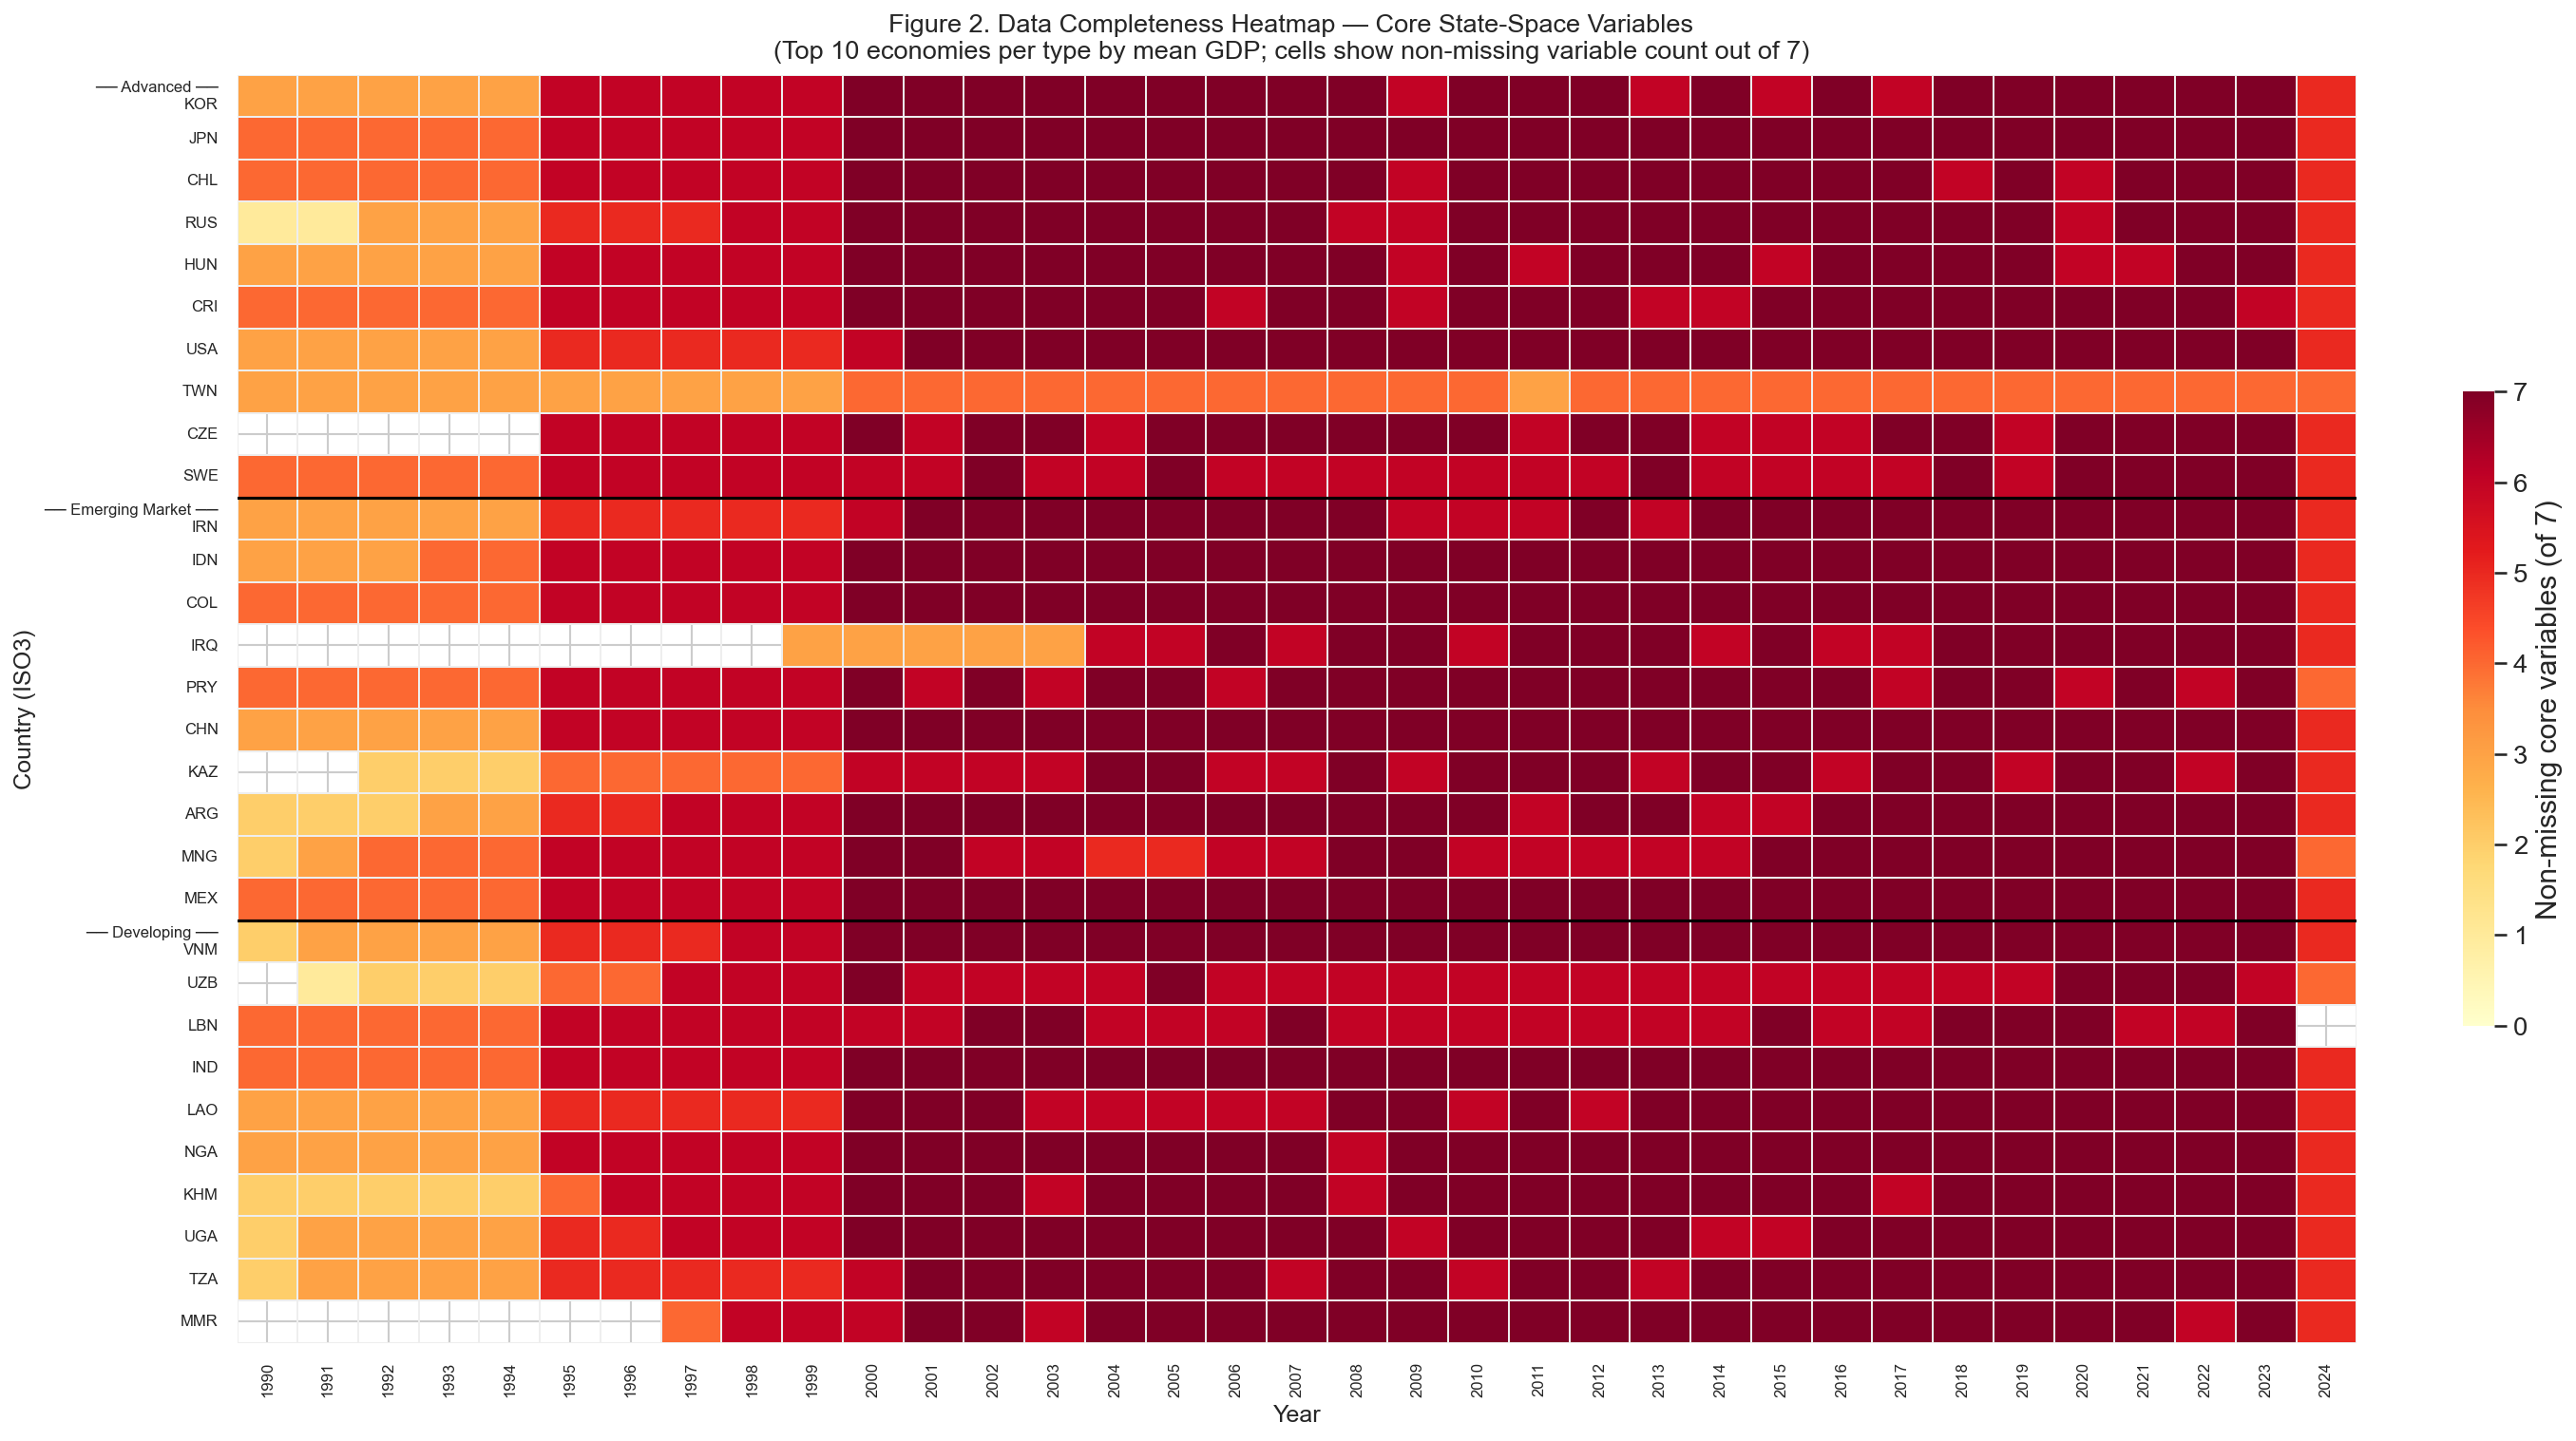

  Saved: fig_02_temporal_coverage_heatmap.png  |  fig_02_temporal_coverage_heatmap.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [7]:
try:
    CORE_VARS = [
        "debt_to_gdp",
        "gdp_growth",
        "weo_primary_balance",
        "weo_inflation_cpi",
        "ndgain_vulnerability",
        "ndgain_readiness",
        "climate_damage_adj_000usd",
    ]

    # Select top-10 countries per economy type by mean GDP
    sample_isos = []
    sample_labels = {}  # iso3 → economy_type label for y-axis grouping
    for etype in ECON_ORDER:
        sub = df_analysis[df_analysis["economy_type"] == etype]
        top10 = (
            sub.groupby("iso3")["weo_gdp_current"]
            .mean()
            .nlargest(10)
            .index.tolist()
        )
        sample_isos.extend(top10)
        for iso in top10:
            sample_labels[iso] = etype

    print(f"Representative sample: {len(sample_isos)} countries")
    for etype in ECON_ORDER:
        group = [k for k, v in sample_labels.items() if v == etype]
        print(f"  {etype}: {group}")

    # Build completeness matrix: count non-null core vars per country-year
    heat_df = df_analysis[df_analysis["iso3"].isin(sample_isos)].copy()
    heat_df["completeness"] = heat_df[CORE_VARS].notna().sum(axis=1)

    pivot = heat_df.pivot_table(
        index="iso3", columns="year", values="completeness", aggfunc="mean"
    )

    # Sort rows by economy type then ISO for grouped display
    row_order = [
        iso for etype in ECON_ORDER
        for iso in sample_isos if sample_labels.get(iso) == etype
    ]
    pivot = pivot.reindex(row_order)

    # y-tick labels with economy type separator markers
    ytick_labels = []
    prev_type = None
    for iso in row_order:
        etype = sample_labels[iso]
        if etype != prev_type:
            ytick_labels.append(f"── {etype} ──\n{iso}")
            prev_type = etype
        else:
            ytick_labels.append(iso)

    fig, ax = plt.subplots(figsize=(18, 10), constrained_layout=True)

    sns.heatmap(
        pivot,
        cmap="YlOrRd",
        vmin=0, vmax=len(CORE_VARS),
        ax=ax,
        linewidths=0.2,
        linecolor="#eeeeee",
        cbar_kws={"label": f"Non-missing core variables (of {len(CORE_VARS)})",
                   "shrink": 0.5},
        yticklabels=ytick_labels,
    )

    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Country (ISO3)", fontsize=12)
    ax.tick_params(axis="x", rotation=90, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

    # Draw horizontal lines separating economy type groups
    boundaries = [0]
    for etype in ECON_ORDER:
        n = sum(1 for v in sample_labels.values() if v == etype)
        boundaries.append(boundaries[-1] + n)
    for b in boundaries[1:-1]:
        ax.axhline(b, color="black", linewidth=1.5)

    fig.suptitle(
        "Figure 2. Data Completeness Heatmap — Core State-Space Variables\n"
        "(Top 10 economies per type by mean GDP; cells show non-missing variable count out of 7)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_02_temporal_coverage_heatmap")
    plt.close(fig)

except Exception:
    print("Figure 2 FAILED:")
    traceback.print_exc()

---
## Figure 3 — Missingness Profile

**What it shows:** A horizontal bar chart of percentage missing values for each variable  
that feeds the RL state space, reward function, or feature engineering. Bars are sorted  
from highest to lowest missingness and colour-coded by data source.

**Why it matters:** This figure goes in the methodology section to justify imputation  
decisions. For example, `weo_output_gap` (87% missing) and `climate_damage_adj_000usd`  
(68% missing because most country-years have zero recorded disasters) require different  
treatment — the former needs careful imputation; the latter is correctly filled with 0.

**Chapter:** 3 — Methodology subsection

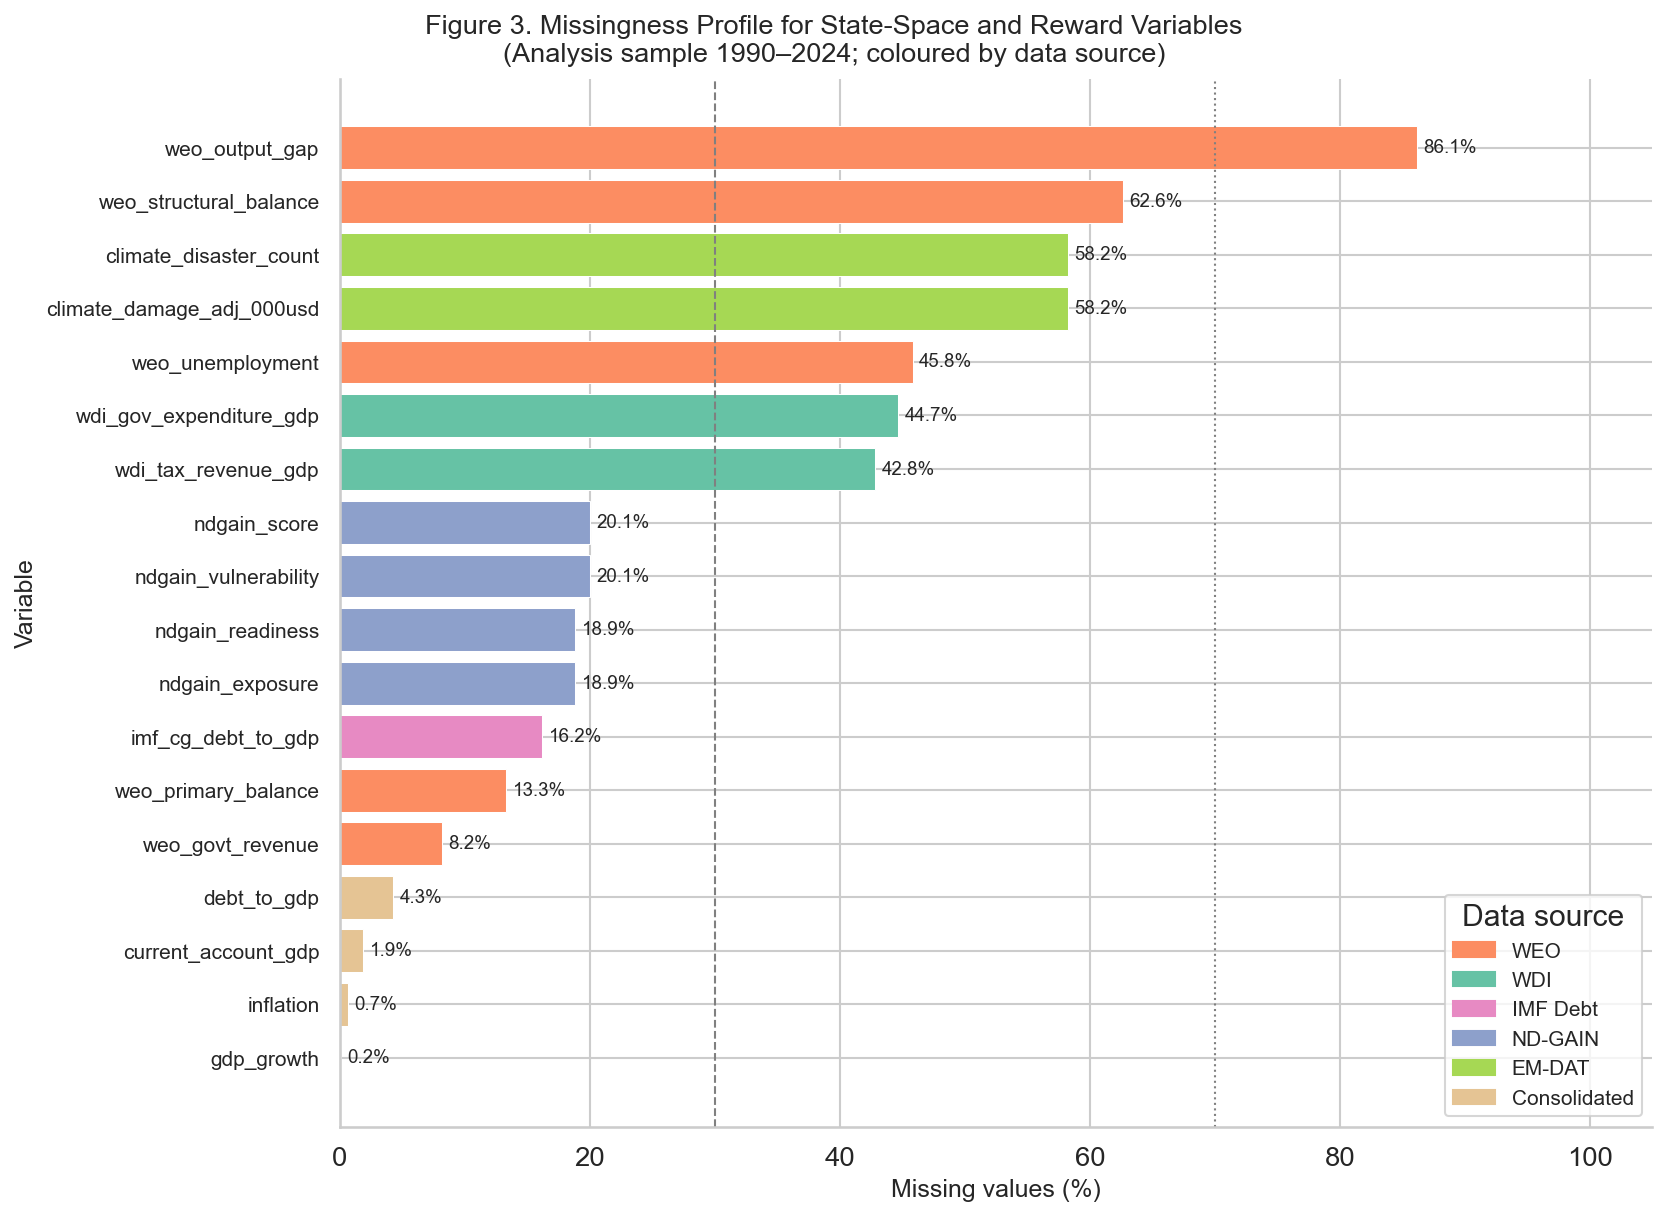

  Saved: fig_03_missingness_profile.png  |  fig_03_missingness_profile.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [8]:
try:
    # Variables to include, with their source labels
    MISS_VARS = {
        # Consolidated (priority cascade)
        "debt_to_gdp":              "Consolidated",
        "gdp_growth":               "Consolidated",
        "inflation":                "Consolidated",
        "current_account_gdp":      "Consolidated",
        # WEO
        "weo_primary_balance":      "WEO",
        "weo_output_gap":           "WEO",
        "weo_structural_balance":   "WEO",
        "weo_unemployment":         "WEO",
        "weo_govt_revenue":         "WEO",
        # WDI
        "wdi_tax_revenue_gdp":      "WDI",
        "wdi_gov_expenditure_gdp":  "WDI",
        # IMF Debt
        "imf_cg_debt_to_gdp":       "IMF Debt",
        # ND-GAIN
        "ndgain_vulnerability":     "ND-GAIN",
        "ndgain_readiness":         "ND-GAIN",
        "ndgain_score":             "ND-GAIN",
        "ndgain_exposure":          "ND-GAIN",
        # EM-DAT
        "climate_disaster_count":   "EM-DAT",
        "climate_damage_adj_000usd":"EM-DAT",
    }

    miss_pct = {
        col: df_analysis[col].isna().mean() * 100
        for col in MISS_VARS
        if col in df_analysis.columns
    }
    miss_series = (
        pd.DataFrame.from_dict(
            {"variable": list(miss_pct.keys()),
             "missing_pct": list(miss_pct.values()),
             "source": [MISS_VARS[c] for c in miss_pct]},
        )
        .sort_values("missing_pct", ascending=True)
        .reset_index(drop=True)
    )

    bar_colors = [SOURCE_COLORS.get(s, "grey") for s in miss_series["source"]]

    fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)

    bars = ax.barh(
        miss_series["variable"],
        miss_series["missing_pct"],
        color=bar_colors,
        edgecolor="white",
        linewidth=0.5,
    )

    # Value labels on bars
    for bar, pct in zip(bars, miss_series["missing_pct"]):
        ax.text(
            pct + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%",
            va="center", ha="left", fontsize=9
        )

    # Reference lines
    for threshold, style in [(30, "--"), (70, ":")]:
        ax.axvline(threshold, color="grey", linestyle=style, linewidth=1,
                   label=f"{threshold}% threshold")

    # Source legend
    legend_patches = [
        mpatches.Patch(color=SOURCE_COLORS[s], label=s)
        for s in SOURCE_COLORS
        if s in MISS_VARS.values()
    ]
    ax.legend(handles=legend_patches, loc="lower right", title="Data source", fontsize=10)

    ax.set_xlabel("Missing values (%)", fontsize=12)
    ax.set_ylabel("Variable", fontsize=12)
    ax.set_xlim(0, 105)
    ax.tick_params(axis="y", labelsize=10)

    fig.suptitle(
        "Figure 3. Missingness Profile for State-Space and Reward Variables\n"
        "(Analysis sample 1990–2024; coloured by data source)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_03_missingness_profile")
    plt.close(fig)

except Exception:
    print("Figure 3 FAILED:")
    traceback.print_exc()

---
## Figure 4 — Sample Size by Economy Type and Decade

**What it shows:** A grouped bar chart showing the number of valid country-year observations  
(i.e., where debt_to_gdp and gdp_growth are both non-missing) per economy type per decade.

**Why it matters:** The examiner needs to see that each cell of the 3×3 experimental matrix  
has enough data to train a statistically meaningful RL agent. Very thin decades (e.g., 2020s  
for Developing economies) might need to be treated as out-of-sample test data only.

**Chapter:** 3 — Data Description

Observations used: 6,216 (both debt_to_gdp and gdp_growth non-null)
   economy_type decade  n_obs
       Advanced  1990s    542
       Advanced  2000s    651
       Advanced  2010s    670
       Advanced  2020s    335
Emerging Market  1990s    394
Emerging Market  2000s    505
Emerging Market  2010s    518
Emerging Market  2020s    255
     Developing  1990s    583
     Developing  2000s    704
     Developing  2010s    710
     Developing  2020s    349


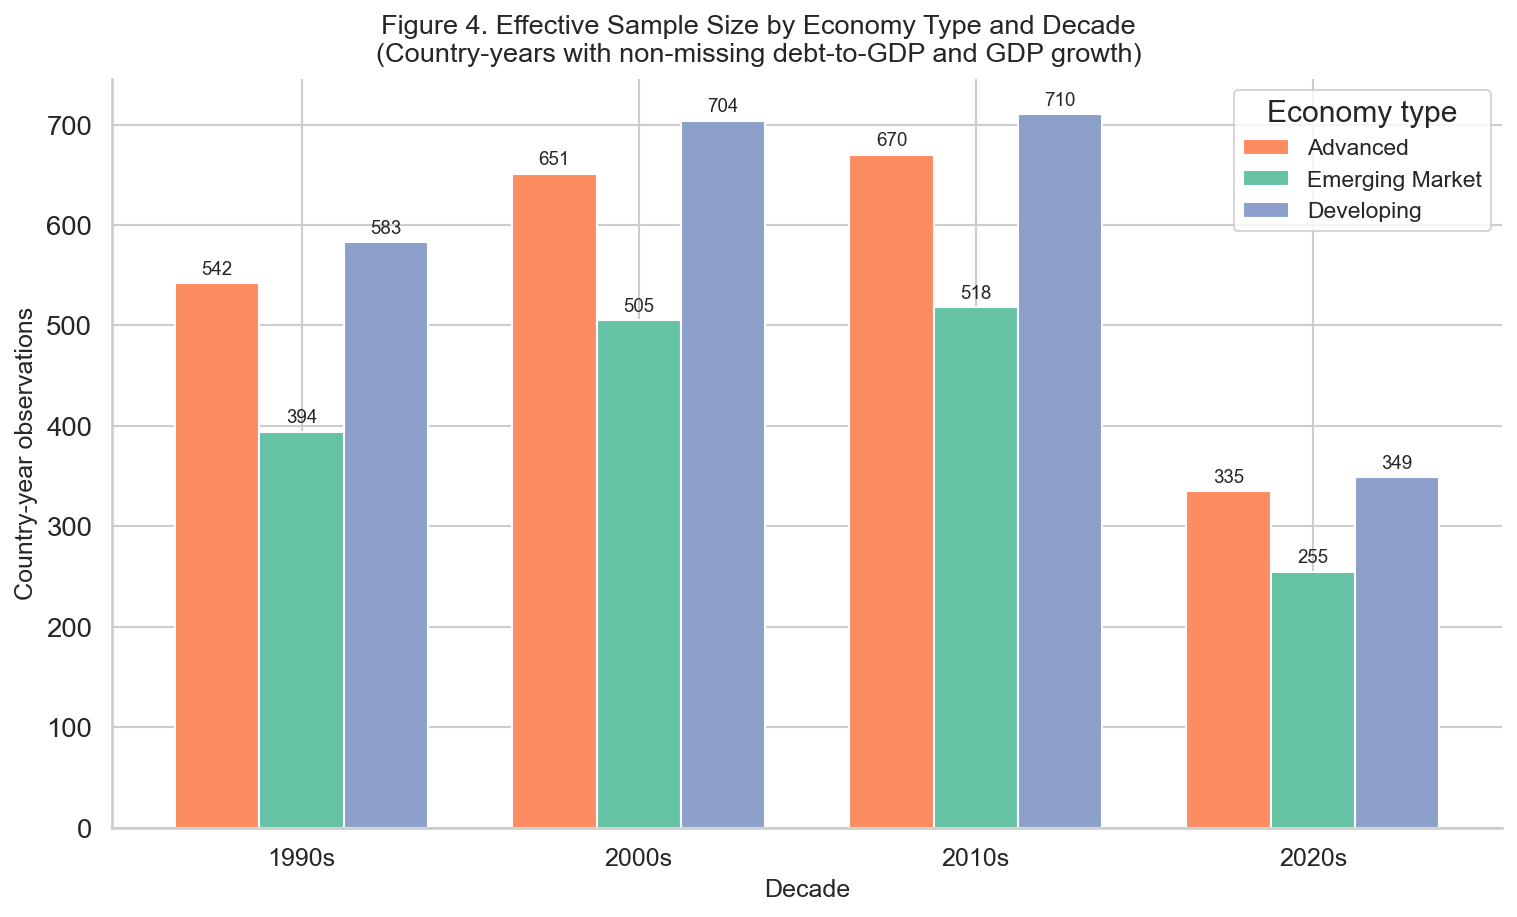

  Saved: fig_04_sample_size_economy_decade.png  |  fig_04_sample_size_economy_decade.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [9]:
try:
    def assign_decade(year):
        if 1990 <= year <= 1999: return "1990s"
        if 2000 <= year <= 2009: return "2000s"
        if 2010 <= year <= 2019: return "2010s"
        if 2020 <= year <= 2024: return "2020s"
        return None

    df4 = df_analysis.copy()
    df4["decade"] = df4["year"].apply(assign_decade)

    # Count rows where both core state variables are non-missing
    df4_valid = df4[
        df4["debt_to_gdp"].notna() &
        df4["gdp_growth"].notna() &
        df4["economy_type"].notna() &
        df4["decade"].notna()
    ]

    decade_counts = (
        df4_valid
        .groupby(["economy_type", "decade"], observed=True)
        .size()
        .reset_index(name="n_obs")
    )

    decade_order = ["1990s", "2000s", "2010s", "2020s"]
    decade_counts["decade"] = pd.Categorical(decade_counts["decade"], categories=decade_order, ordered=True)
    decade_counts["economy_type"] = pd.Categorical(decade_counts["economy_type"], categories=ECON_ORDER, ordered=True)
    decade_counts = decade_counts.sort_values(["economy_type", "decade"])

    print(f"Observations used: {len(df4_valid):,} (both debt_to_gdp and gdp_growth non-null)")
    print(decade_counts.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

    x     = np.arange(len(decade_order))
    width = 0.25

    for i, etype in enumerate(ECON_ORDER):
        sub = decade_counts[decade_counts["economy_type"] == etype].set_index("decade").reindex(decade_order)
        rects = ax.bar(
            x + (i - 1) * width,
            sub["n_obs"].fillna(0),
            width,
            label=etype,
            color=ECON_COLORS[etype],
            edgecolor="white",
        )
        for rect in rects:
            h = rect.get_height()
            if h > 0:
                ax.text(
                    rect.get_x() + rect.get_width() / 2,
                    h + 5,
                    f"{int(h):,}",
                    ha="center", va="bottom", fontsize=9
                )

    ax.set_xticks(x)
    ax.set_xticklabels(decade_order, fontsize=12)
    ax.set_xlabel("Decade", fontsize=12)
    ax.set_ylabel("Country-year observations", fontsize=12)
    ax.legend(title="Economy type", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

    fig.suptitle(
        "Figure 4. Effective Sample Size by Economy Type and Decade\n"
        "(Country-years with non-missing debt-to-GDP and GDP growth)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_04_sample_size_economy_decade")
    plt.close(fig)

except Exception:
    print("Figure 4 FAILED:")
    traceback.print_exc()

---
## Figure 5 — Distribution of Key State Variables by Economy Type

**What it shows:** A 2×3 grid of KDE (kernel density estimate) plots, one per state  
variable. Each panel overlays the three economy type distributions so you can see  
whether they are distinct or heavily overlapping. A vertical dashed line shows the  
median for each group.

**Why it matters:** If the distributions overlap completely, training separate RL agents  
per economy type provides no additional benefit over a single agent. Distinct distributions  
justify the 3×3 matrix design. This is a key methodological argument in Chapter 4.

**Chapter:** 3 — Data Description / 4 — Justification of experimental design

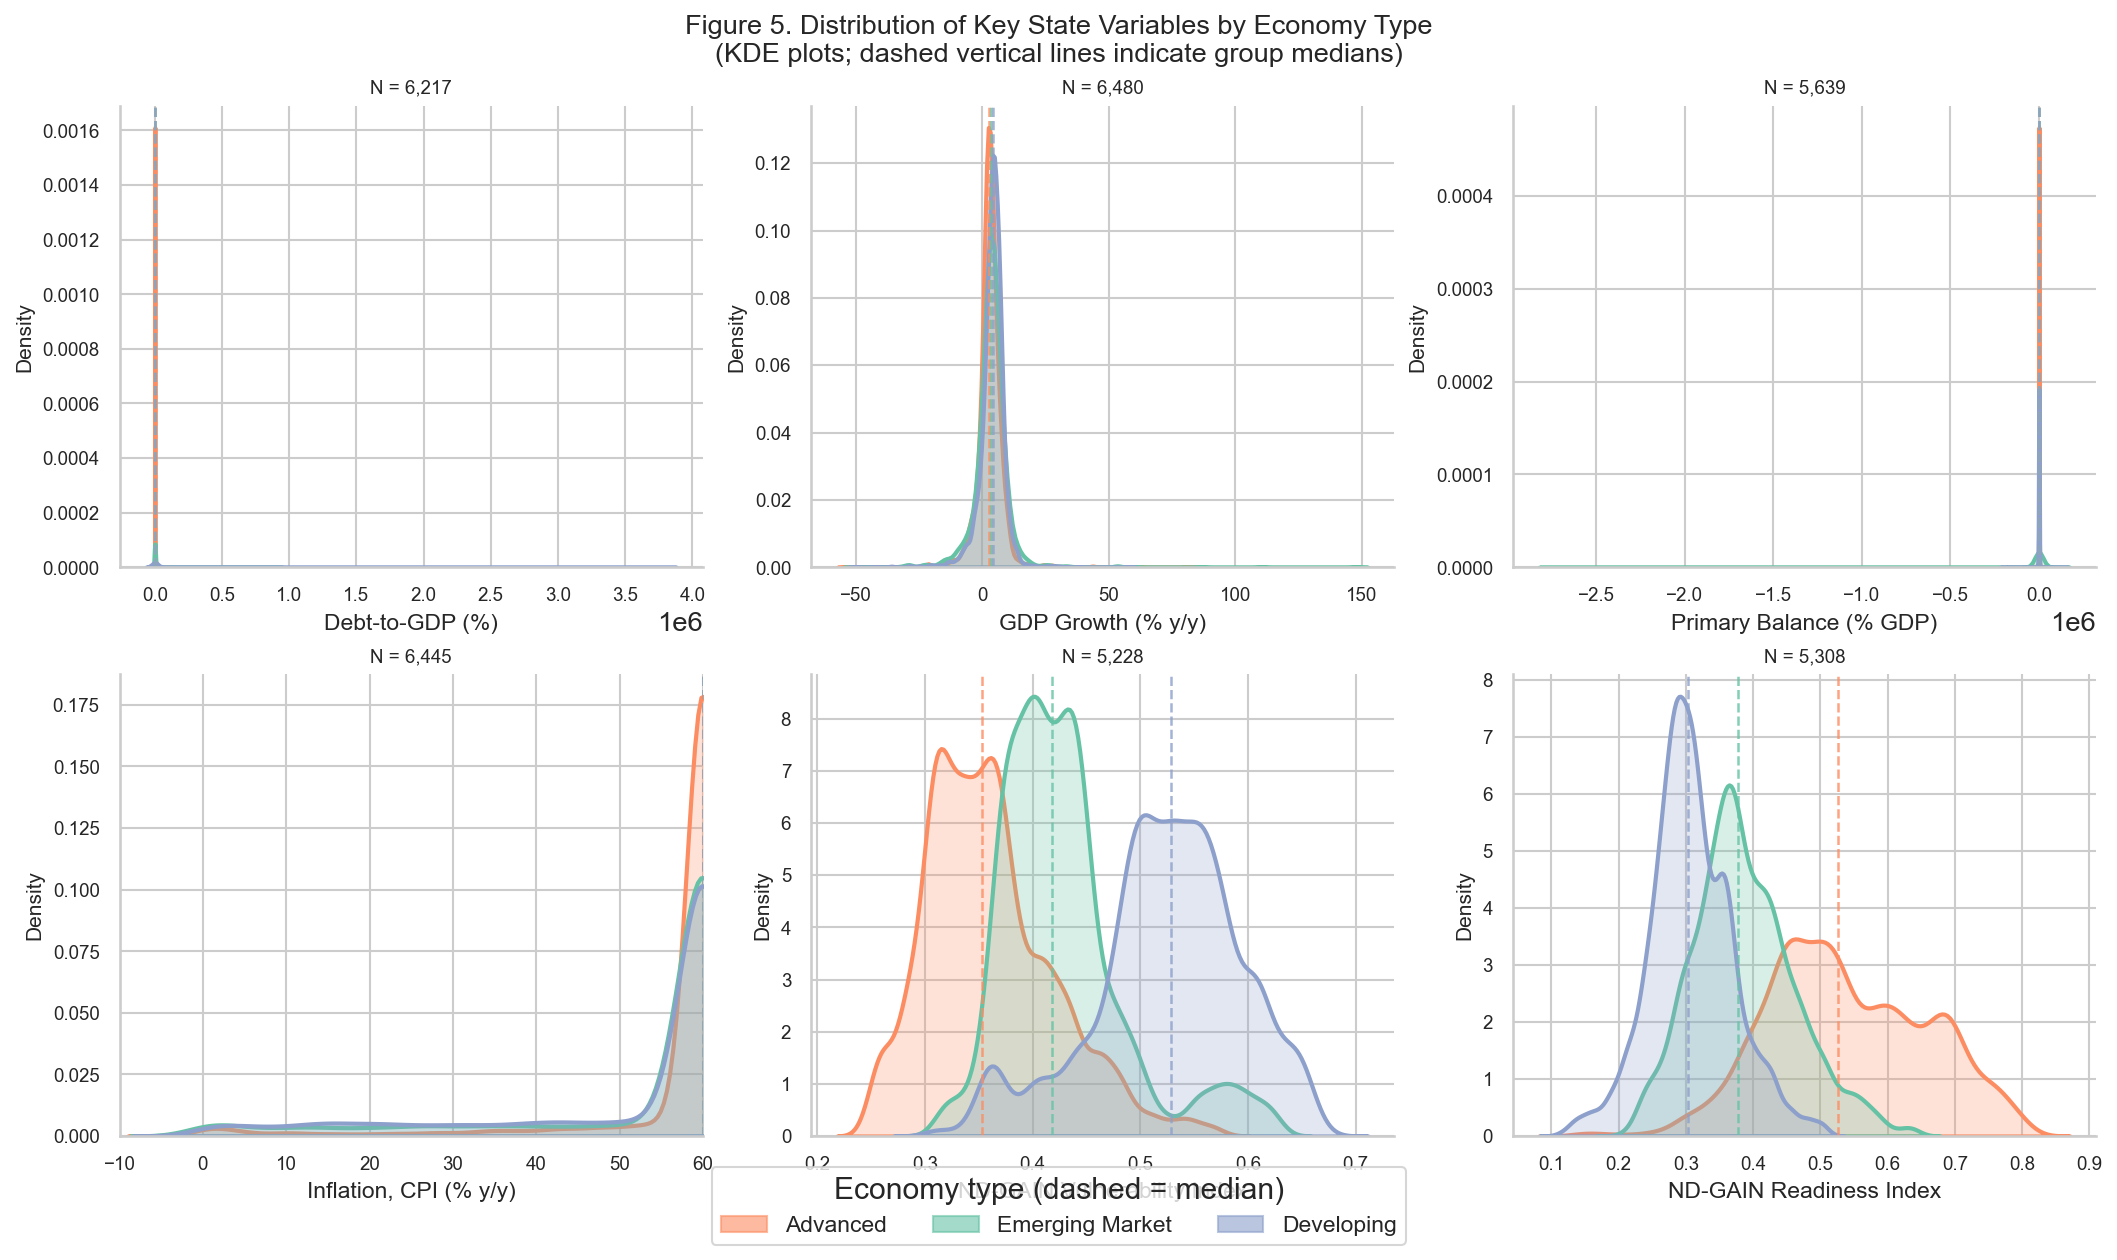

  Saved: fig_05_state_variable_distributions.png  |  fig_05_state_variable_distributions.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [10]:
try:
    DIST_VARS = [
        ("debt_to_gdp",         "Debt-to-GDP (%)",            None),
        ("gdp_growth",          "GDP Growth (% y/y)",          None),
        ("weo_primary_balance", "Primary Balance (% GDP)",     None),
        ("inflation",           "Inflation, CPI (% y/y)",      (-10, 60)),
        ("ndgain_vulnerability","ND-GAIN Vulnerability Index", None),
        ("ndgain_readiness",    "ND-GAIN Readiness Index",     None),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

    for ax, (col, xlabel, xlim) in zip(axes.flat, DIST_VARS):
        sub = df_analysis[df_analysis["economy_type"].notna()].dropna(subset=[col, "economy_type"])
        n_total = len(sub)

        for etype in ECON_ORDER:
            vals = sub.loc[sub["economy_type"] == etype, col]
            if xlim:
                vals = vals.clip(*xlim)
            if len(vals) < 10:
                continue
            sns.kdeplot(
                vals,
                ax=ax,
                label=etype,
                color=ECON_COLORS[etype],
                fill=True,
                alpha=0.25,
                linewidth=2,
                bw_adjust=0.8,
                warn_singular=False,
            )
            median_val = vals.median()
            ax.axvline(
                median_val,
                color=ECON_COLORS[etype],
                linestyle="--",
                linewidth=1.2,
                alpha=0.8,
            )

        if xlim:
            ax.set_xlim(xlim)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel("Density", fontsize=10)
        ax.set_title(f"N = {n_total:,}", fontsize=9)
        ax.tick_params(labelsize=9)

    # Shared legend outside grid
    handles = [
        mpatches.Patch(color=ECON_COLORS[et], alpha=0.6, label=et)
        for et in ECON_ORDER
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=3,
        fontsize=11,
        title="Economy type (dashed = median)",
        bbox_to_anchor=(0.5, -0.04),
    )

    fig.suptitle(
        "Figure 5. Distribution of Key State Variables by Economy Type\n"
        "(KDE plots; dashed vertical lines indicate group medians)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_05_state_variable_distributions")
    plt.close(fig)

except Exception:
    print("Figure 5 FAILED:")
    traceback.print_exc()

---
## Figure 6 — Box Plots of State Variables by Economy Type

**What it shows:** The same 6 variables as Figure 5, now displayed as box plots grouped  
by economy type. Box plots explicitly show the median, IQR, and outliers — information  
KDE plots hide. Policy-relevant reference lines are added (60% debt-to-GDP Maastricht  
criterion; 0% for primary balance separating surplus from deficit).

**Why it matters:** Complements Figure 5. Together they give the examiner both the  
shape of the distribution (KDE) and the key summary statistics (boxplot). Outliers are  
visible as individual points, which is important because extreme macroeconomic events  
(hyperinflation, debt crises) are exactly what the RL agent should learn to avoid.

**Chapter:** 3 — Data Description

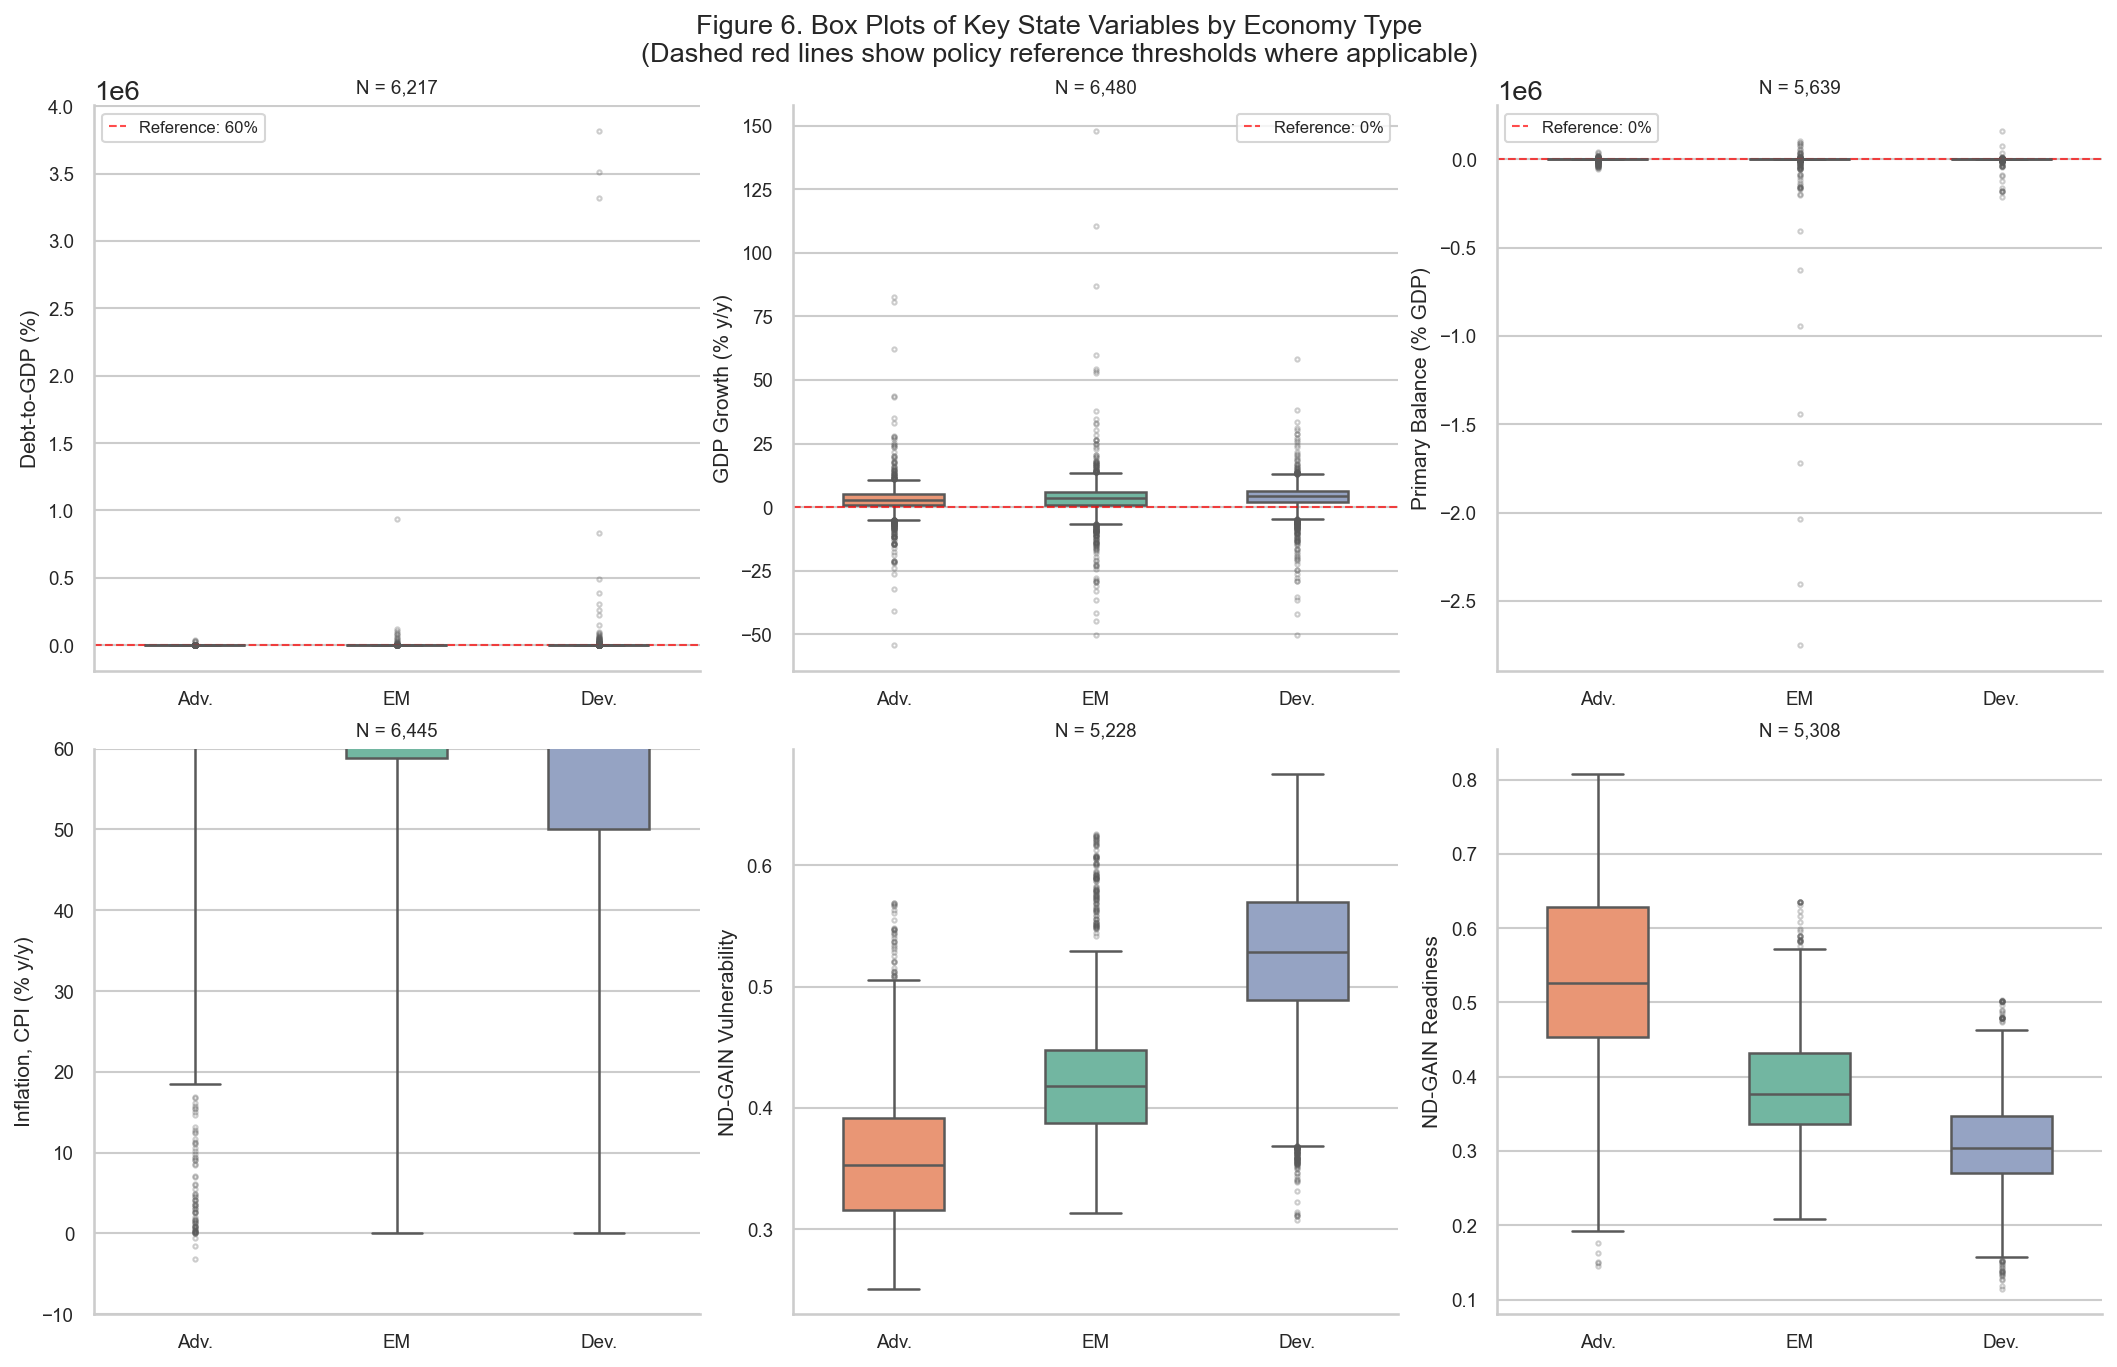

  Saved: fig_06_state_variable_boxplots.png  |  fig_06_state_variable_boxplots.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [11]:
try:
    BOX_VARS = [
        ("debt_to_gdp",         "Debt-to-GDP (%)",            60,  None),
        ("gdp_growth",          "GDP Growth (% y/y)",          0,   None),
        ("weo_primary_balance", "Primary Balance (% GDP)",     0,   None),
        ("inflation",           "Inflation, CPI (% y/y)",      None,(-10, 60)),
        ("ndgain_vulnerability","ND-GAIN Vulnerability",       None,None),
        ("ndgain_readiness",    "ND-GAIN Readiness",           None,None),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)

    for ax, (col, ylabel, hline, ylim) in zip(axes.flat, BOX_VARS):
        plot_df = df_analysis[df_analysis["economy_type"].notna()].dropna(subset=[col, "economy_type"])
        n_obs   = len(plot_df)

        palette = {et: ECON_COLORS[et] for et in ECON_ORDER}

        sns.boxplot(
            data=plot_df,
            x="economy_type",
            y=col,
            order=ECON_ORDER,
            palette=palette,
            ax=ax,
            width=0.5,
            fliersize=2,
            flierprops={"alpha": 0.3},
            linewidth=1.2,
            showfliers=True,
        )

        if hline is not None:
            ax.axhline(
                hline,
                color="red",
                linestyle="--",
                linewidth=1,
                alpha=0.7,
                label=f"Reference: {hline}%",
            )
            ax.legend(fontsize=8, handlelength=1)

        if ylim:
            ax.set_ylim(ylim)

        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xlabel("")
        ax.set_title(f"N = {n_obs:,}", fontsize=9)
        ax.set_xticklabels(
            ["Adv.", "EM", "Dev."],
            fontsize=10,
        )
        ax.tick_params(labelsize=9)

    fig.suptitle(
        "Figure 6. Box Plots of Key State Variables by Economy Type\n"
        "(Dashed red lines show policy reference thresholds where applicable)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_06_state_variable_boxplots")
    plt.close(fig)

except Exception:
    print("Figure 6 FAILED:")
    traceback.print_exc()

---
## Figure 7 — Correlation Heatmap of State Space Variables

**What it shows:** Spearman rank-correlation matrix for all variables entering the RL  
state space and reward function. Spearman is preferred over Pearson because  
macroeconomic time series frequently have fat tails and non-linear relationships.

**Why it matters:** High pairwise correlation (|ρ| > 0.8) signals potential  
multicollinearity that could destabilise the DQN/PPO value function estimates.  
This figure informs feature engineering decisions (e.g., whether to orthogonalise  
highly correlated inputs or drop one of the pair).

**Chapter:** 3 — Data Description / Methodology

Effective N: 6,610 rows (at least one variable non-null)
Variables included: ['debt_to_gdp', 'gdp_growth', 'weo_primary_balance', 'inflation', 'ndgain_vulnerability', 'ndgain_readiness', 'current_account_gdp', 'weo_output_gap', 'wdi_tax_revenue_gdp', 'climate_damage_adj_000usd', 'climate_disaster_count']


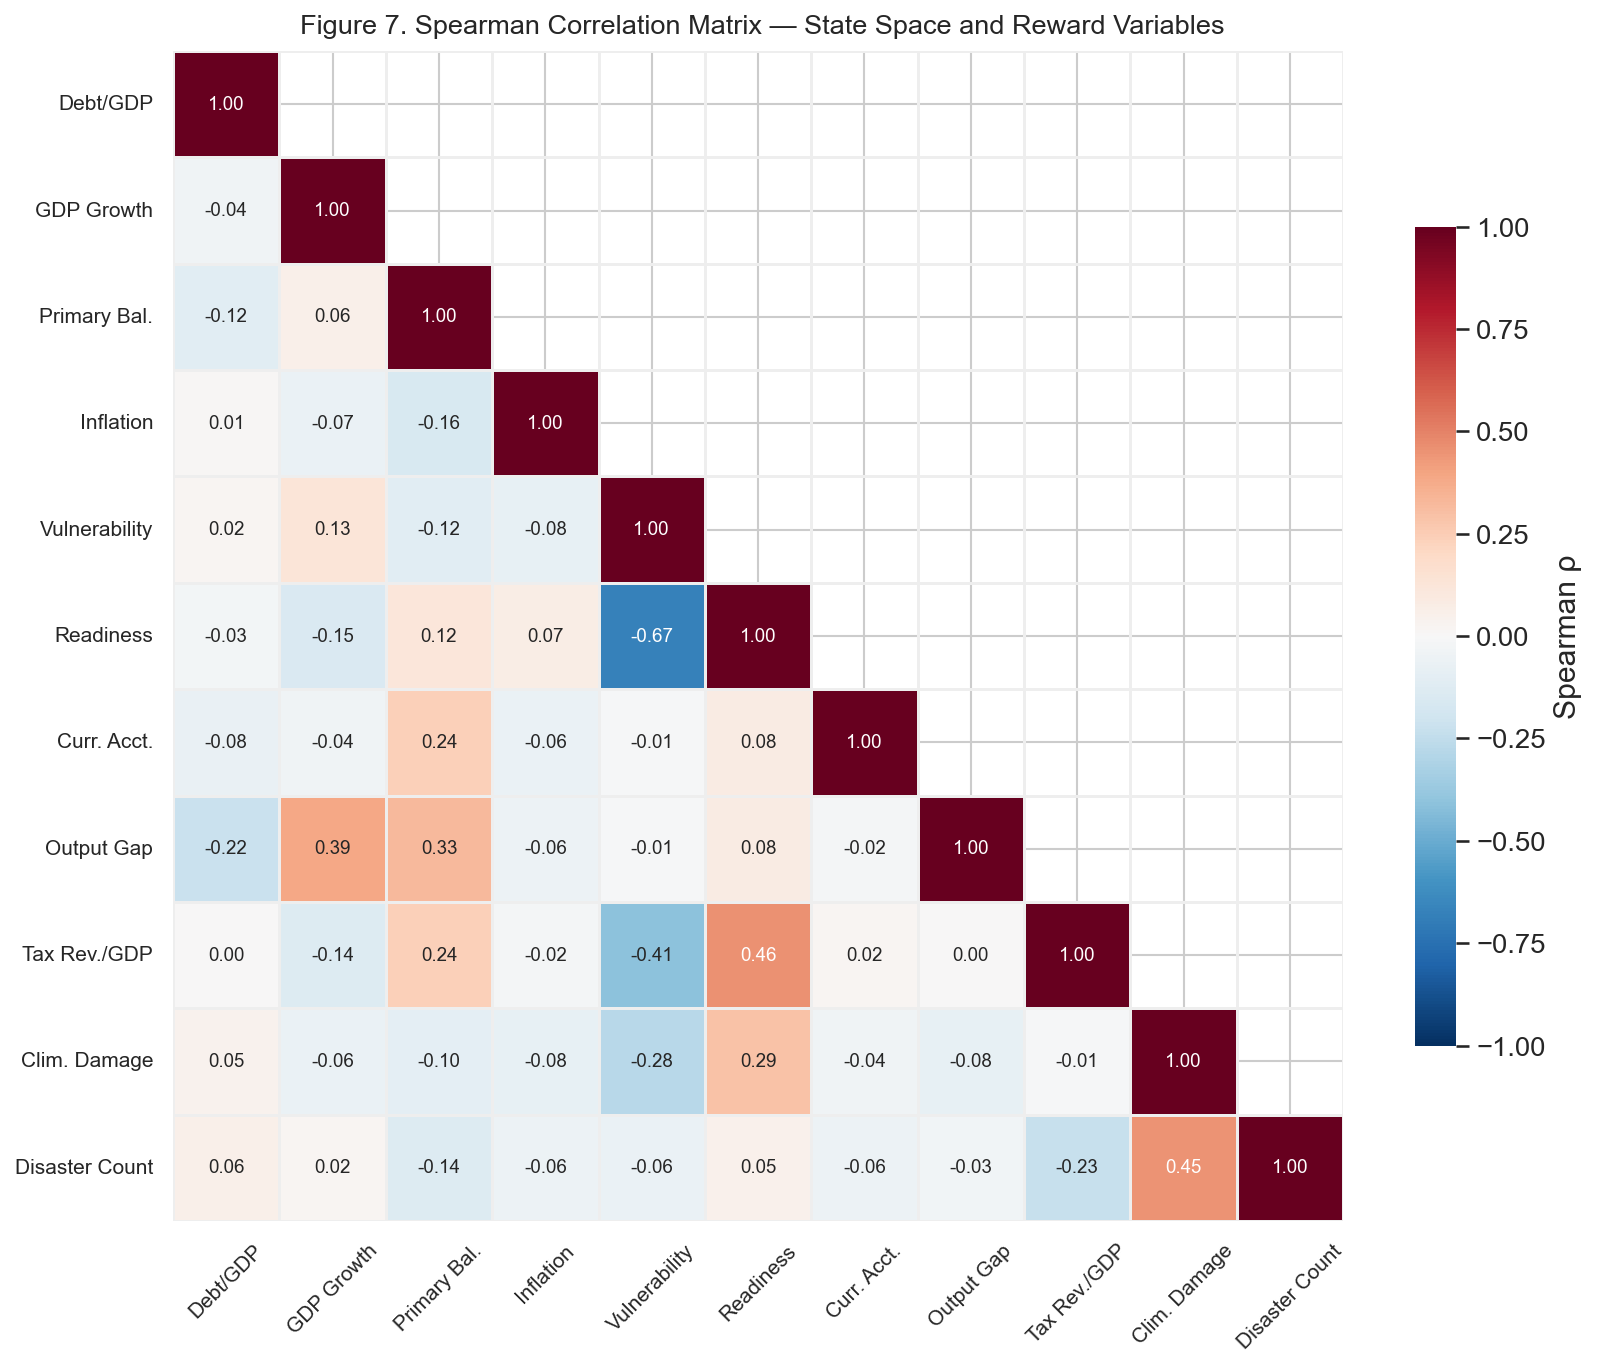

  Saved: fig_07_correlation_heatmap.png  |  fig_07_correlation_heatmap.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures

--- Pairwise correlations with |ρ| > 0.80 ---
  None found — no pairwise correlation exceeds |0.80|.


In [ ]:
try:
    CORR_VARS = [
        "debt_to_gdp",
        "gdp_growth",
        "weo_primary_balance",
        "inflation",
        "ndgain_vulnerability",
        "ndgain_readiness",
        "current_account_gdp",
        "weo_output_gap",
        "wdi_tax_revenue_gdp",
        "climate_damage_adj_000usd",
        "climate_disaster_count",
    ]
    present_corr = [c for c in CORR_VARS if c in df_analysis.columns]
    corr_df = df_analysis[present_corr].dropna(how="all")

    # Effective N per pair varies; minimum is printed below
    spearman_matrix = corr_df.corr(method="spearman")

    print(f"Effective N: {len(corr_df):,} rows (at least one variable non-null)")
    print(f"Variables included: {present_corr}")

    # Pretty labels for axes
    CORR_LABELS = {
        "debt_to_gdp":              "Debt/GDP",
        "gdp_growth":               "GDP Growth",
        "weo_primary_balance":      "Primary Bal.",
        "inflation":                "Inflation",
        "ndgain_vulnerability":     "Vulnerability",
        "ndgain_readiness":         "Readiness",
        "current_account_gdp":      "Curr. Acct.",
        "weo_output_gap":           "Output Gap",
        "wdi_tax_revenue_gdp":      "Tax Rev./GDP",
        "climate_damage_adj_000usd":"Clim. Damage",
        "climate_disaster_count":   "Disaster Count",
    }
    labels = [CORR_LABELS.get(c, c) for c in spearman_matrix.columns]

    # Mask upper triangle
    mask = np.triu(np.ones_like(spearman_matrix, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)

    sns.heatmap(
        spearman_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1, vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        linecolor="#eeeeee",
        annot_kws={"size": 9},
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"shrink": 0.7, "label": "Spearman ρ"},
        ax=ax,
    )

    ax.tick_params(axis="x", rotation=45, labelsize=10)
    ax.tick_params(axis="y", rotation=0,  labelsize=10)

    fig.suptitle(
        "Figure 7. Spearman Correlation Matrix — State Space and Reward Variables",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_07_correlation_heatmap")
    plt.close(fig)

    # Flag high correlations
    print("\n--- Pairwise correlations with |ρ| > 0.80 ---")
    high_corr_found = False
    cols = spearman_matrix.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = spearman_matrix.iloc[i, j]
            if abs(r) > 0.80:
                print(f"  {cols[i]:30s} × {cols[j]:30s}  ρ = {r:.3f}  *** MULTICOLLINEARITY RISK")
                high_corr_found = True
    if not high_corr_found:
        print("  None found — no pairwise correlation exceeds |0.80|.")

except Exception:
    print("Figure 7 FAILED:")
    traceback.print_exc()

---
## Figure 8 — Temporal Trends in Debt-to-GDP by Economy Type

**What it shows:** Median debt-to-GDP over 1990–2024, one line per economy type, with  
shaded IQR (25th–75th percentile). This reveals the structural fiscal trajectory of each  
economy group and how they diverged — especially after the 2008 Global Financial Crisis  
and the 2020 COVID shock.

**Why it matters:** The RL agent's reward function penalises high debt burdens. If  
Advanced economies carry far more debt than Developing ones, the agents will have  
structurally different reward landscapes — justifying separate training per economy type.

**Chapter:** 3/4 — Empirical motivation and results context

Observations used: 6,217


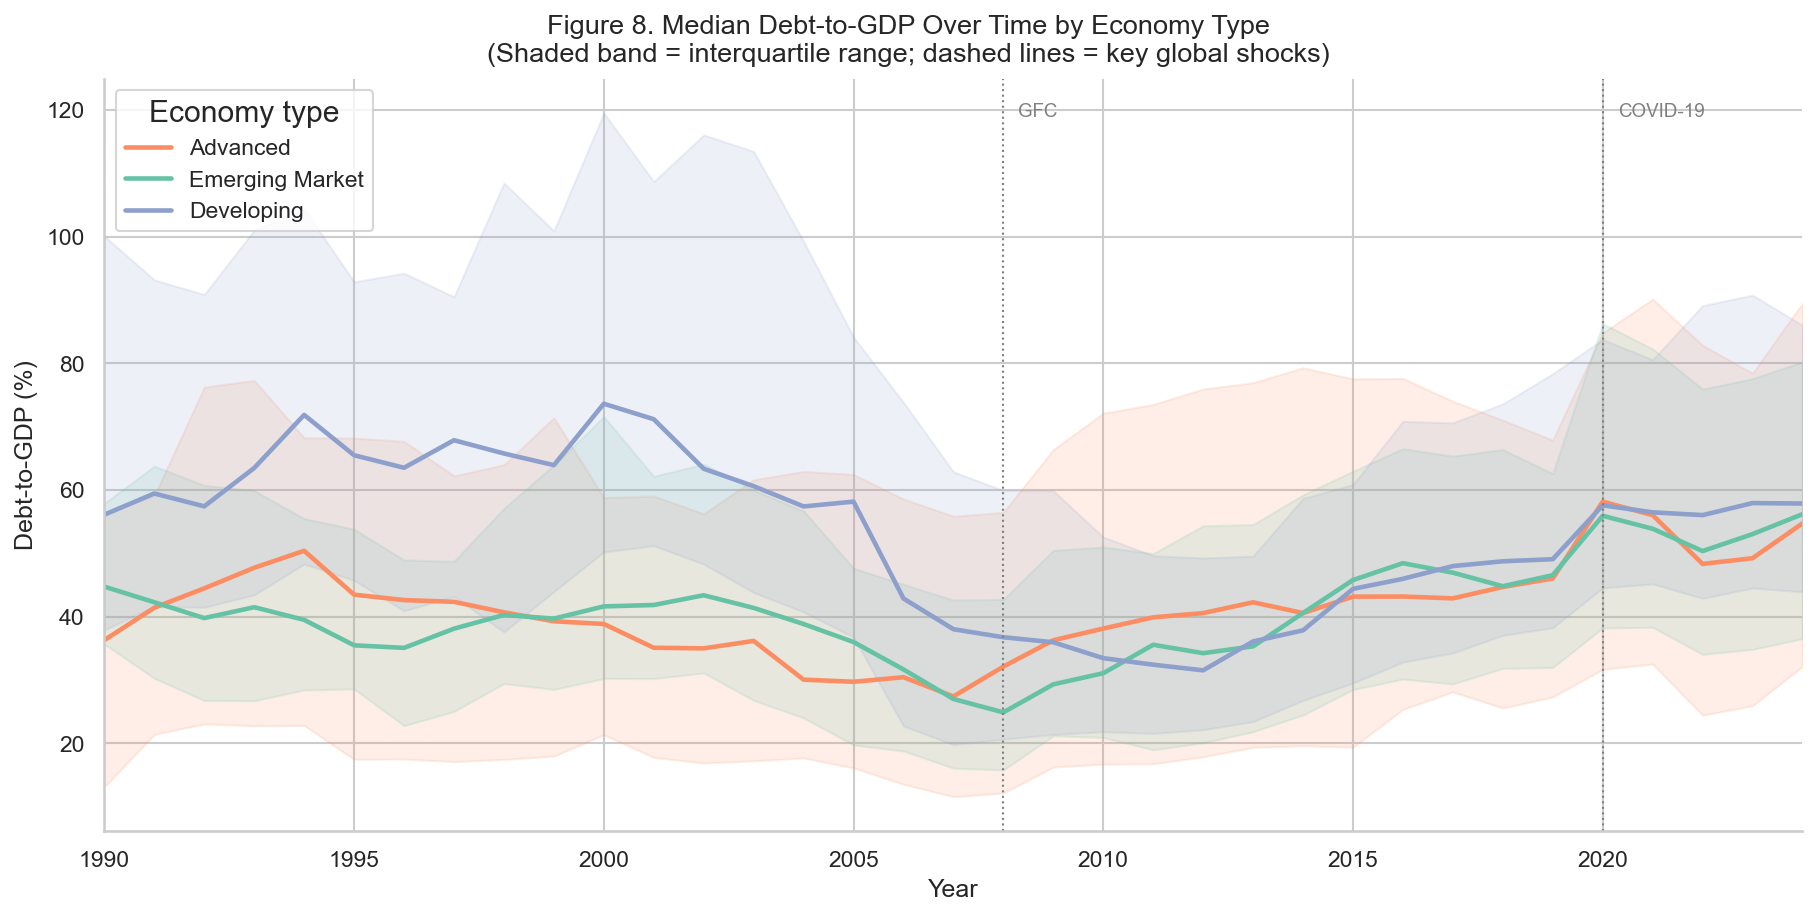

  Saved: fig_08_debt_trends_by_economy.png  |  fig_08_debt_trends_by_economy.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [13]:
try:
    df8 = df_analysis.dropna(subset=["debt_to_gdp", "economy_type"]).copy()
    print(f"Observations used: {len(df8):,}")

    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

    for etype in ECON_ORDER:
        sub  = df8[df8["economy_type"] == etype]
        grp  = sub.groupby("year")["debt_to_gdp"]
        med  = grp.median()
        p25  = grp.quantile(0.25)
        p75  = grp.quantile(0.75)
        col  = ECON_COLORS[etype]

        ax.plot(med.index, med.values, color=col, linewidth=2.2, label=etype)
        ax.fill_between(med.index, p25.values, p75.values, color=col, alpha=0.15)

    # Annotate key macro events
    for year, label in [(2008, "GFC"), (2020, "COVID-19")]:
        ax.axvline(year, color="grey", linestyle=":", linewidth=1)
        ax.text(year + 0.3, ax.get_ylim()[1] * 0.97, label,
                fontsize=9, color="grey", va="top")

    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Debt-to-GDP (%)", fontsize=12)
    ax.legend(title="Economy type", fontsize=11, loc="upper left")
    ax.tick_params(labelsize=11)
    ax.set_xlim(1990, 2024)

    fig.suptitle(
        "Figure 8. Median Debt-to-GDP Over Time by Economy Type\n"
        "(Shaded band = interquartile range; dashed lines = key global shocks)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_08_debt_trends_by_economy")
    plt.close(fig)

except Exception:
    print("Figure 8 FAILED:")
    traceback.print_exc()

---
## Figure 9 — Temporal Trends in Climate Damages by Economy Type

**What it shows:** Two-panel figure. Top panel: median annual climate damage (adjusted  
thousands USD) over time by economy type with IQR bands, using a log-scale y-axis  
because damages span several orders of magnitude. Bottom panel: median disaster count  
over time by economy type.

**Why it matters:** Establishes the temporal pattern of the climate fiscal stress  
that the RL agent must navigate. If damages are trending upward (consistent with  
climate change), the agent's training environment must reflect this non-stationarity.

**Chapter:** 3/4 — Climate-fiscal nexus section

Observations: 6,487 (NaN climate = 0 for trend plots)


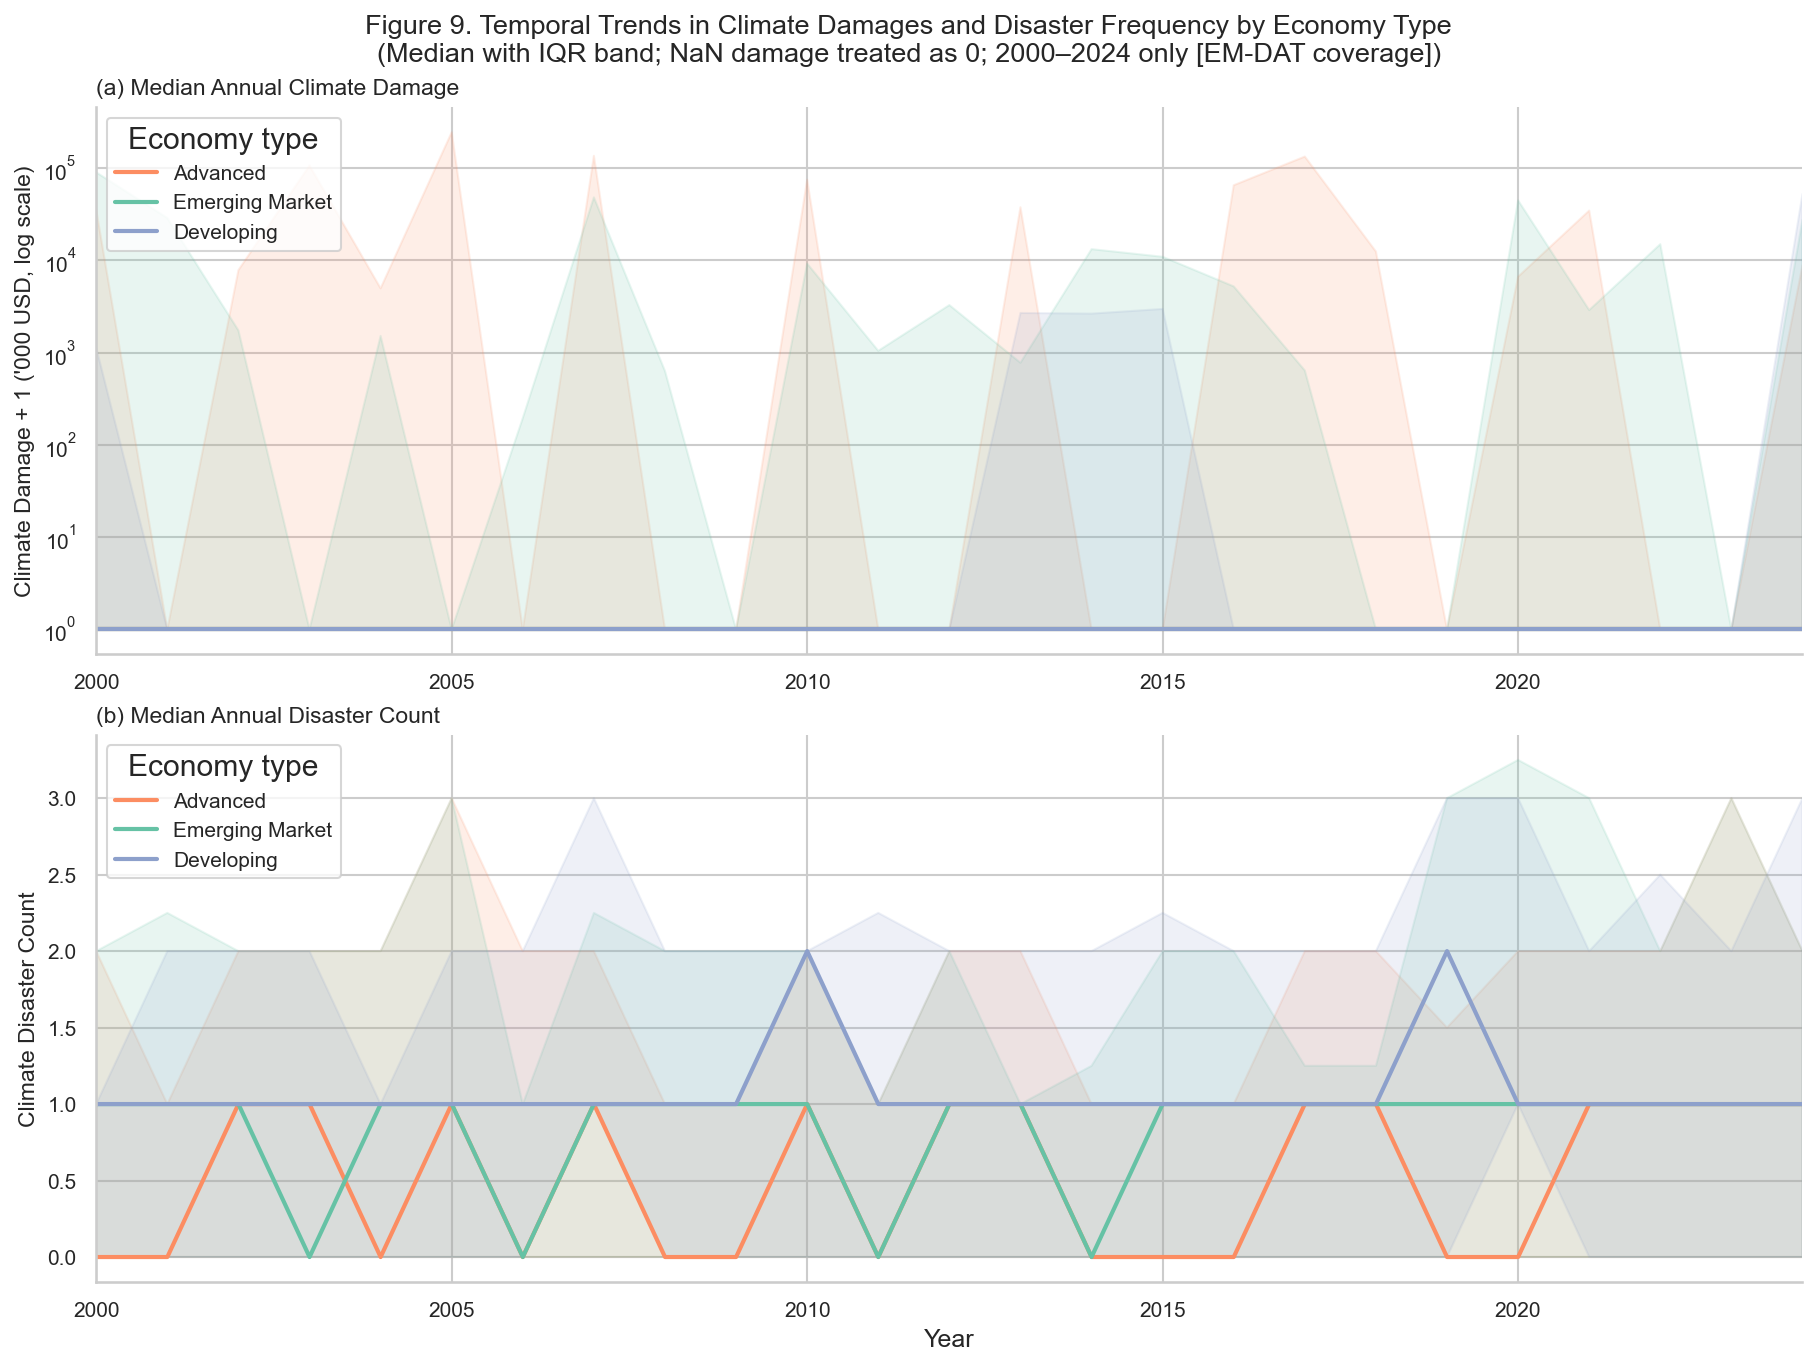

  Saved: fig_09_climate_damage_trends.png  |  fig_09_climate_damage_trends.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [14]:
try:
    # For climate variables, NaN means no disaster — treat as 0 for median/IQR
    df9 = df_analysis.copy()
    df9["climate_damage_adj_000usd"] = df9["climate_damage_adj_000usd"].fillna(0)
    df9["climate_disaster_count"]    = df9["climate_disaster_count"].fillna(0)
    df9 = df9.dropna(subset=["economy_type"])
    print(f"Observations: {len(df9):,} (NaN climate = 0 for trend plots)")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), constrained_layout=True)

    for etype in ECON_ORDER:
        sub = df9[df9["economy_type"] == etype]
        col = ECON_COLORS[etype]

        # Panel 1: climate damages (log scale, add 1 to avoid log(0))
        grp  = sub.groupby("year")["climate_damage_adj_000usd"]
        med  = grp.median()
        p25  = grp.quantile(0.25)
        p75  = grp.quantile(0.75)
        ax1.plot(med.index, med.values + 1, color=col, linewidth=2, label=etype)
        ax1.fill_between(med.index, p25.values + 1, p75.values + 1,
                         color=col, alpha=0.15)

        # Panel 2: disaster count
        grp2 = sub.groupby("year")["climate_disaster_count"]
        med2 = grp2.median()
        p25_2= grp2.quantile(0.25)
        p75_2= grp2.quantile(0.75)
        ax2.plot(med2.index, med2.values, color=col, linewidth=2, label=etype)
        ax2.fill_between(med2.index, p25_2.values, p75_2.values,
                         color=col, alpha=0.15)

    ax1.set_yscale("log")
    ax1.set_ylabel("Climate Damage + 1 ('000 USD, log scale)", fontsize=11)
    ax1.set_xlabel("")
    ax1.legend(title="Economy type", fontsize=10, loc="upper left")
    ax1.set_xlim(2000, 2024)
    ax1.set_title("(a) Median Annual Climate Damage", fontsize=11, loc="left")

    ax2.set_ylabel("Climate Disaster Count", fontsize=11)
    ax2.set_xlabel("Year", fontsize=12)
    ax2.legend(title="Economy type", fontsize=10, loc="upper left")
    ax2.set_xlim(2000, 2024)
    ax2.set_title("(b) Median Annual Disaster Count", fontsize=11, loc="left")

    for ax in (ax1, ax2):
        ax.tick_params(labelsize=10)

    fig.suptitle(
        "Figure 9. Temporal Trends in Climate Damages and Disaster Frequency by Economy Type\n"
        "(Median with IQR band; NaN damage treated as 0; 2000–2024 only [EM-DAT coverage])",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_09_climate_damage_trends")
    plt.close(fig)

except Exception:
    print("Figure 9 FAILED:")
    traceback.print_exc()

---
## Figure 10 — Climate Damage vs. Change in Debt-to-GDP

**What it shows:** The central empirical figure. Each point is a country-year observation.  
X-axis: climate damage as a percentage of GDP (computed from adjusted damages in '000 USD  
divided by WEO current GDP in billions USD). Y-axis: year-on-year change in debt-to-GDP.  
Points are coloured by economy type. Separate OLS regression lines with confidence  
intervals are fitted for each economy type.

**Why it matters:** This figure tests the central hypothesis: do larger climate damages  
lead to greater fiscal deterioration? If yes, and the slope differs by economy type,  
it validates the dissertation's claim that climate stress affects sovereign fiscal  
positions heterogeneously.

**Chapter:** 4 — Core analytical results

Observations (after outlier trim): 2,611


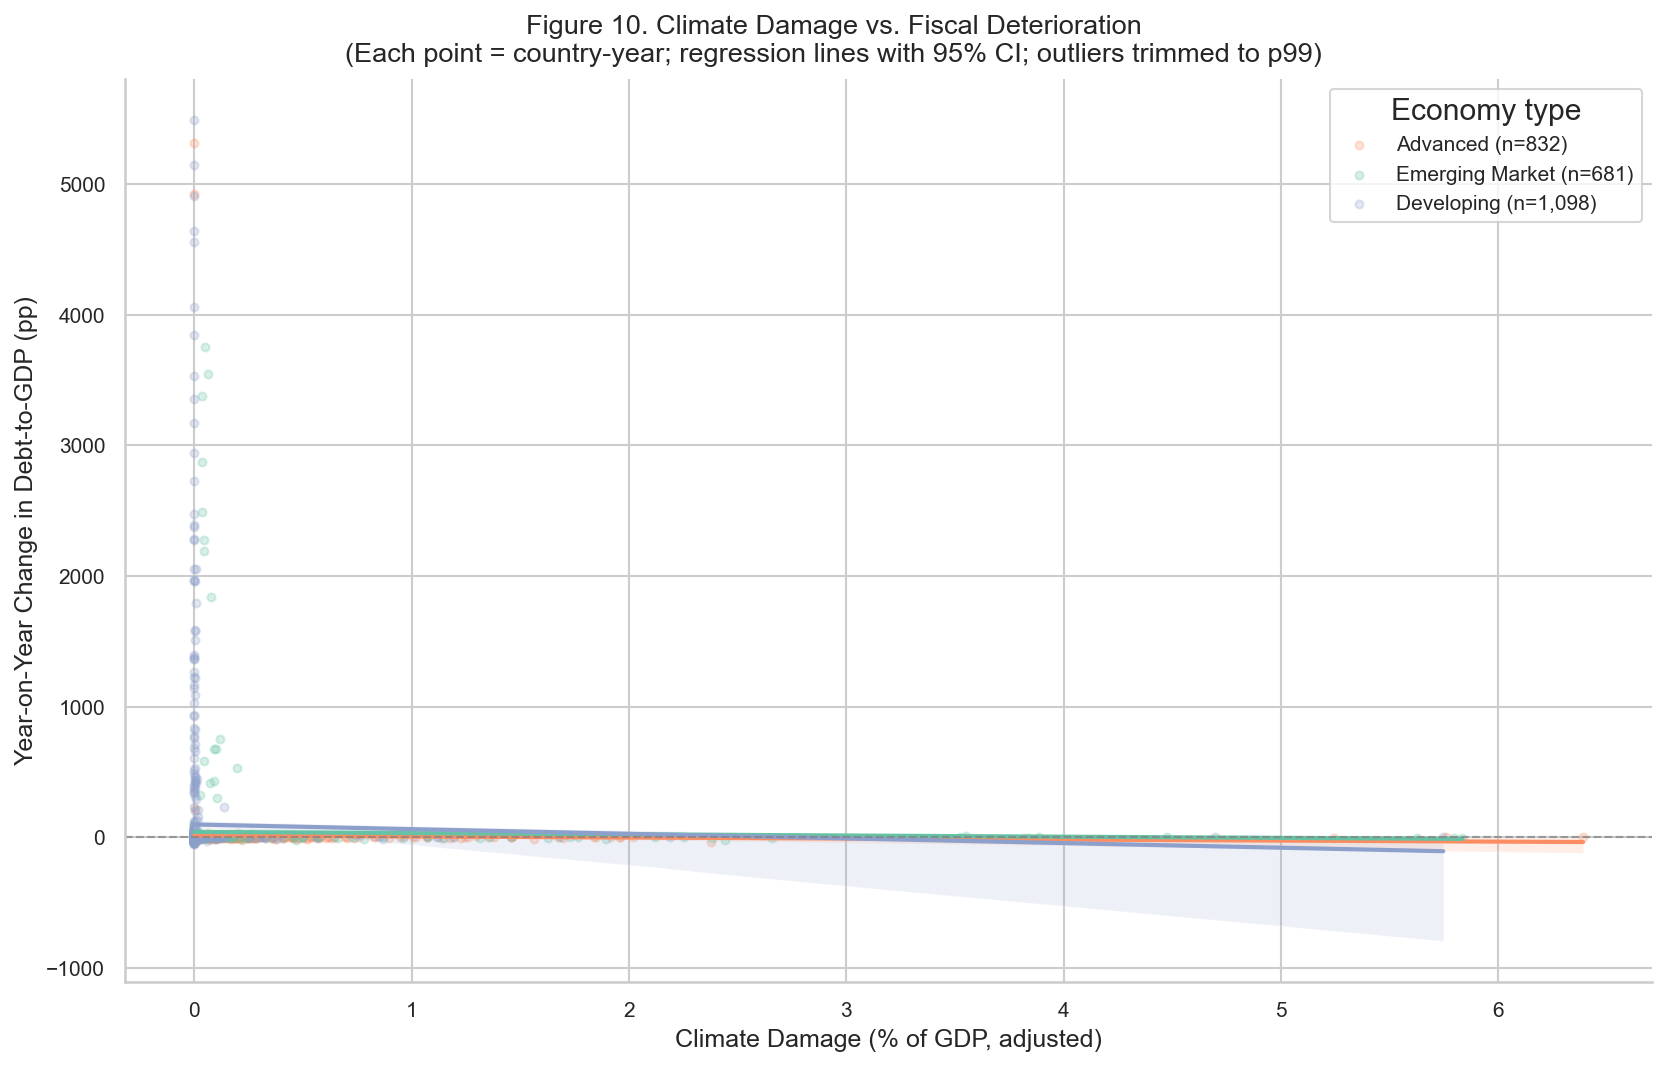

  Saved: fig_10_climate_damage_vs_debt_change.png  |  fig_10_climate_damage_vs_debt_change.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [15]:
try:
    df10 = df_analysis.dropna(
        subset=["climate_damage_pct_gdp", "debt_change", "economy_type"]
    ).copy()

    # Exclude extreme outliers for visual clarity (keep 99th percentile)
    cap_dmg   = df10["climate_damage_pct_gdp"].quantile(0.99)
    cap_ddebt = df10["debt_change"].quantile(0.99)
    floor_ddebt = df10["debt_change"].quantile(0.01)
    df10 = df10[
        (df10["climate_damage_pct_gdp"] <= cap_dmg) &
        (df10["debt_change"] <= cap_ddebt) &
        (df10["debt_change"] >= floor_ddebt)
    ]
    print(f"Observations (after outlier trim): {len(df10):,}")

    fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)

    for etype in ECON_ORDER:
        sub = df10[df10["economy_type"] == etype]
        ax.scatter(
            sub["climate_damage_pct_gdp"],
            sub["debt_change"],
            color=ECON_COLORS[etype],
            alpha=0.25,
            s=15,
            label=f"{etype} (n={len(sub):,})",
            rasterized=True,
        )
        if len(sub) >= 20:
            sns.regplot(
                data=sub,
                x="climate_damage_pct_gdp",
                y="debt_change",
                ax=ax,
                scatter=False,
                color=ECON_COLORS[etype],
                line_kws={"linewidth": 2},
                ci=95,
            )

    ax.axhline(0, color="grey", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel("Climate Damage (% of GDP, adjusted)", fontsize=12)
    ax.set_ylabel("Year-on-Year Change in Debt-to-GDP (pp)", fontsize=12)
    ax.legend(title="Economy type", fontsize=10)
    ax.tick_params(labelsize=10)

    fig.suptitle(
        "Figure 10. Climate Damage vs. Fiscal Deterioration\n"
        "(Each point = country-year; regression lines with 95% CI; outliers trimmed to p99)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_10_climate_damage_vs_debt_change")
    plt.close(fig)

except Exception:
    print("Figure 10 FAILED:")
    traceback.print_exc()

---
## Figure 11 — Climate Vulnerability vs. Fiscal Space

**What it shows:** Scatter plot with ND-GAIN vulnerability on the x-axis (higher = more  
vulnerable to climate change) and WEO primary balance on the y-axis (higher = more fiscal  
space to absorb shocks). Countries are coloured by economy type.

**Why it matters:** Tests the compounding risk hypothesis — the core motivation for the  
dissertation. If the most climate-vulnerable countries also have the least fiscal space,  
they face a double jeopardy that makes sovereign risk assessment especially urgent.  
A negative relationship here would powerfully justify the research.

**Chapter:** 4 — Core analytical results

Observations: 4,861


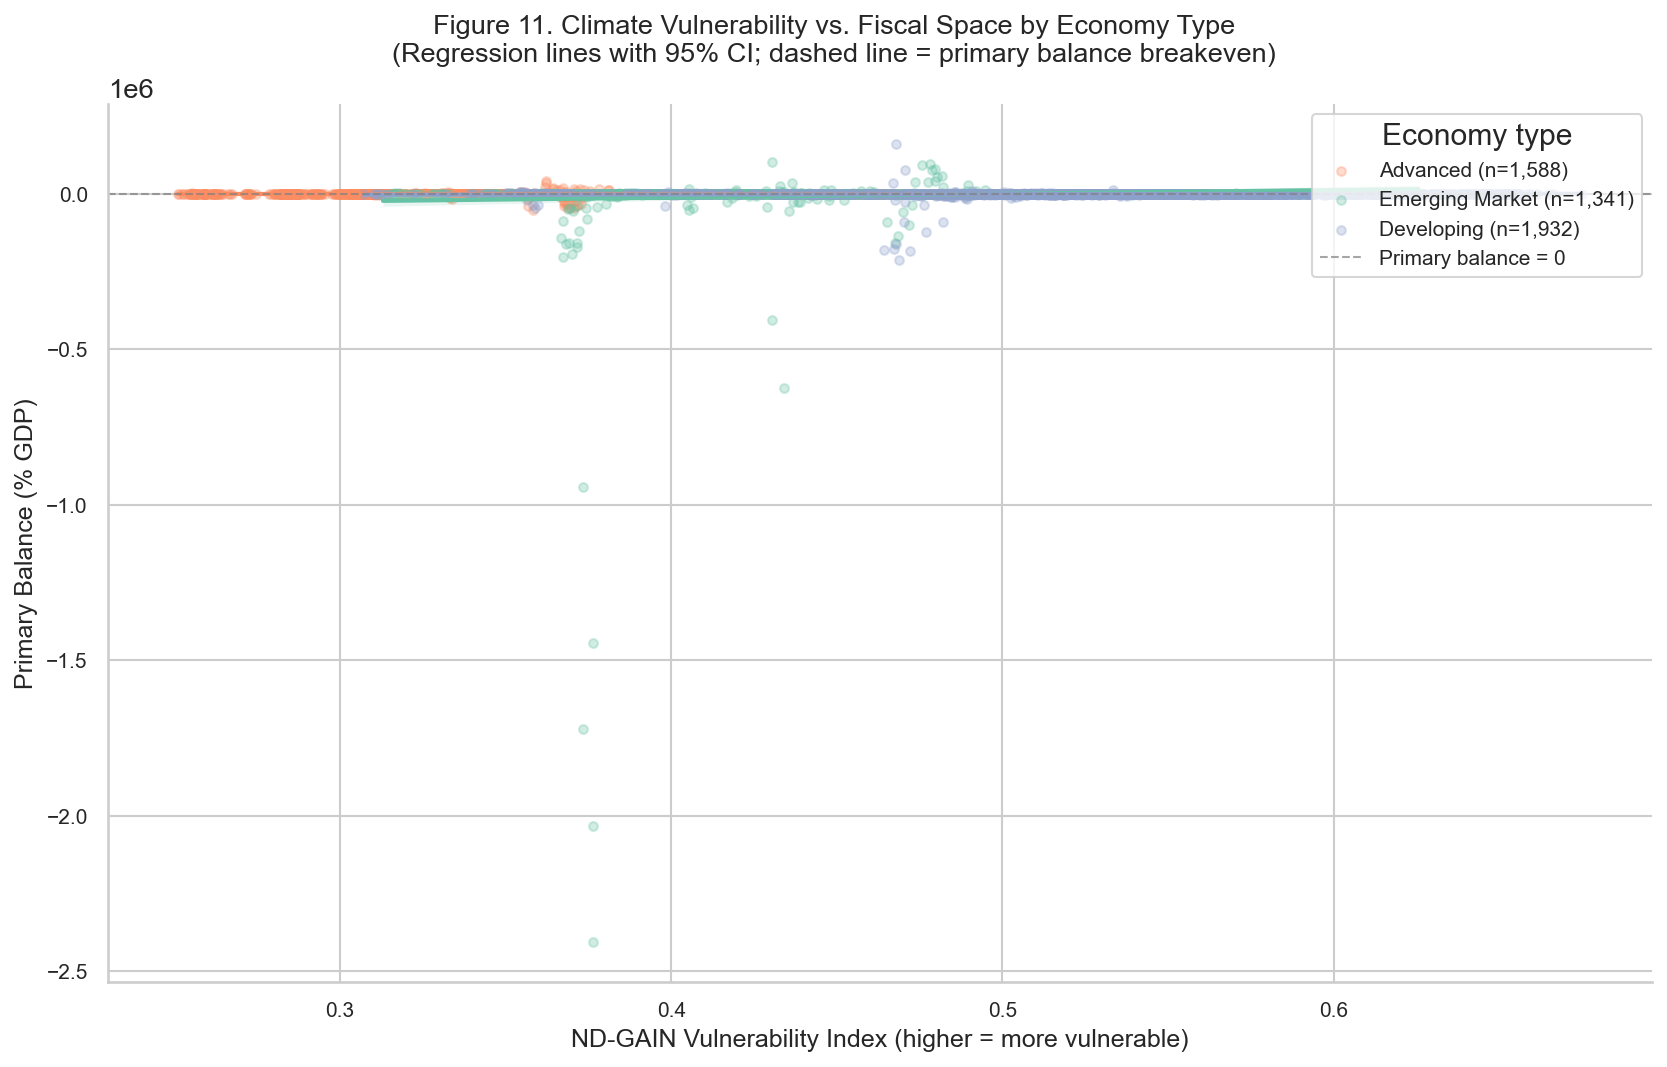

  Saved: fig_11_vulnerability_vs_fiscal_space.png  |  fig_11_vulnerability_vs_fiscal_space.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [16]:
try:
    df11 = df_analysis.dropna(
        subset=["ndgain_vulnerability", "weo_primary_balance", "economy_type"]
    ).copy()
    print(f"Observations: {len(df11):,}")

    fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)

    for etype in ECON_ORDER:
        sub = df11[df11["economy_type"] == etype]
        ax.scatter(
            sub["ndgain_vulnerability"],
            sub["weo_primary_balance"],
            color=ECON_COLORS[etype],
            alpha=0.3,
            s=18,
            label=f"{etype} (n={len(sub):,})",
            rasterized=True,
        )
        if len(sub) >= 20:
            sns.regplot(
                data=sub,
                x="ndgain_vulnerability",
                y="weo_primary_balance",
                ax=ax,
                scatter=False,
                color=ECON_COLORS[etype],
                line_kws={"linewidth": 2},
                ci=95,
            )

    ax.axhline(0, color="grey", linestyle="--", linewidth=1, alpha=0.7,
               label="Primary balance = 0")
    ax.set_xlabel("ND-GAIN Vulnerability Index (higher = more vulnerable)", fontsize=12)
    ax.set_ylabel("Primary Balance (% GDP)", fontsize=12)
    ax.legend(title="Economy type", fontsize=10, loc="upper right")
    ax.tick_params(labelsize=10)

    fig.suptitle(
        "Figure 11. Climate Vulnerability vs. Fiscal Space by Economy Type\n"
        "(Regression lines with 95% CI; dashed line = primary balance breakeven)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_11_vulnerability_vs_fiscal_space")
    plt.close(fig)

except Exception:
    print("Figure 11 FAILED:")
    traceback.print_exc()

---
## Figure 12 — Adaptation Readiness vs. Debt-to-GDP

**What it shows:** ND-GAIN readiness index (proxy for adaptation capital) on the x-axis  
vs. consolidated debt-to-GDP on the y-axis. Economy type coloured.

**Why it matters:** Tests whether countries with higher adaptive capacity also tend to  
have lower debt — which would be the 'virtuous cycle' outcome — or whether highly  
indebted countries are also unable to invest in adaptation (the 'debt trap' hypothesis).  
The shape of this relationship directly informs the RL reward function design.

**Chapter:** 4

Observations: 5,206


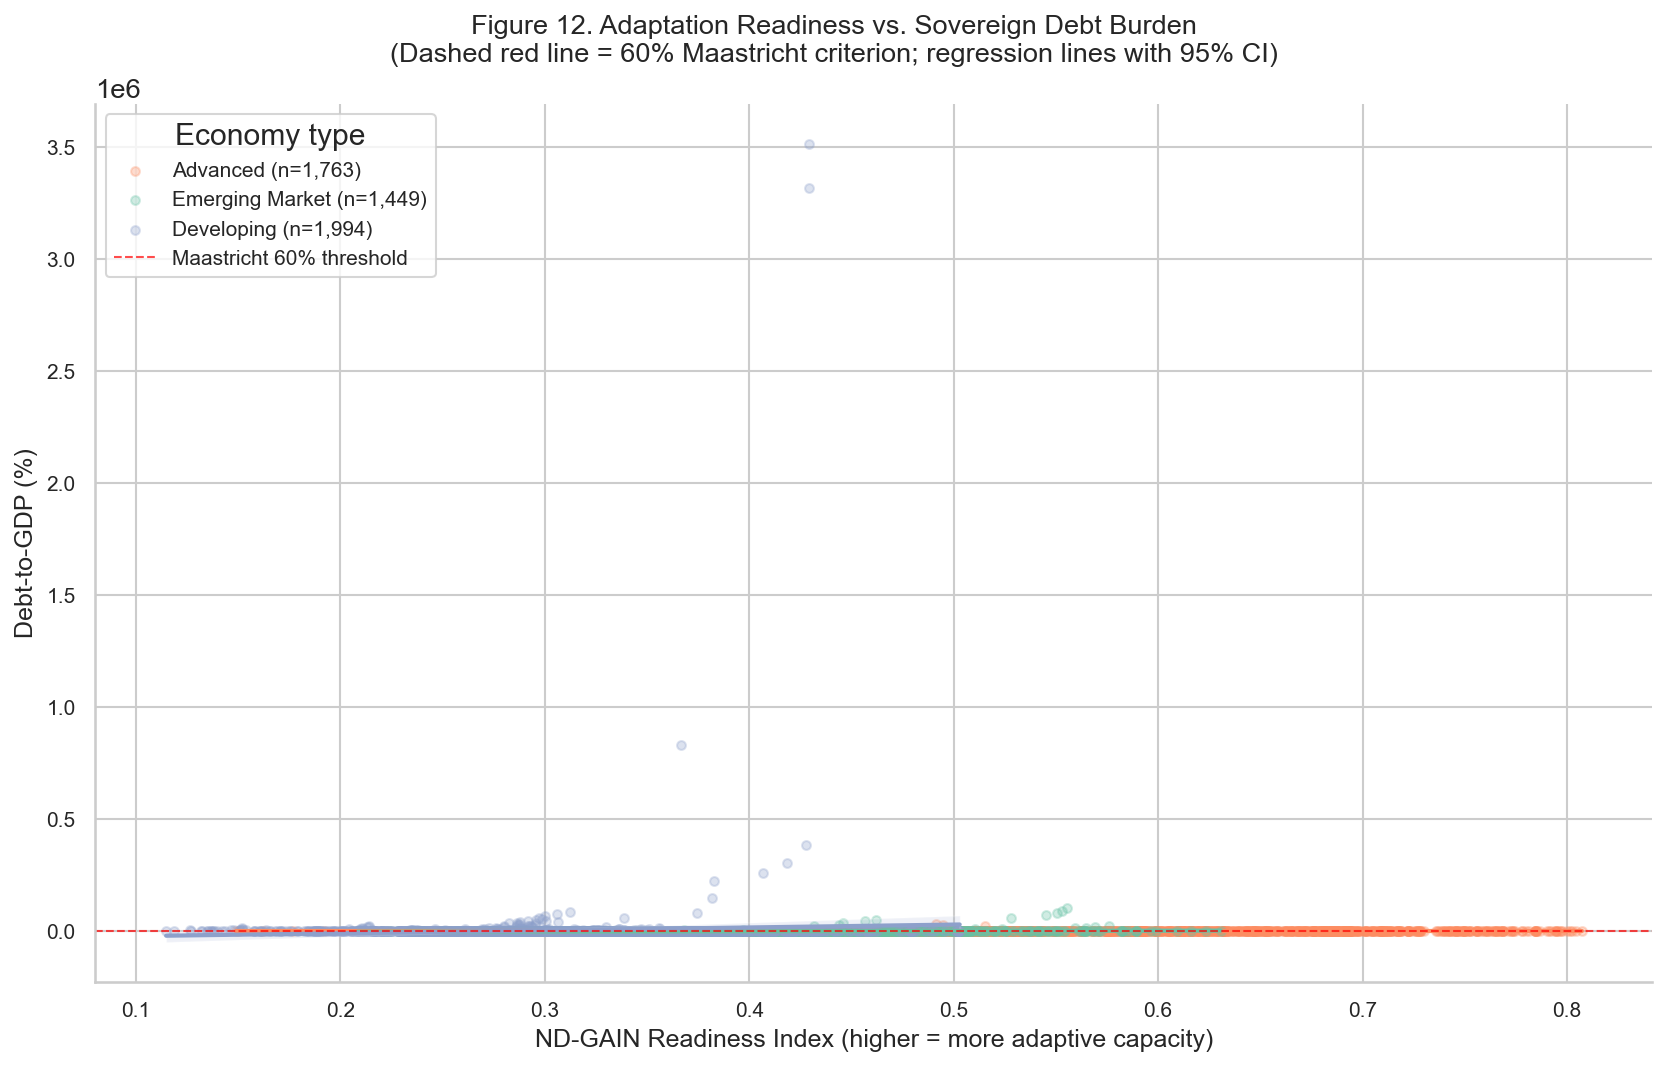

  Saved: fig_12_readiness_vs_debt.png  |  fig_12_readiness_vs_debt.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [17]:
try:
    df12 = df_analysis.dropna(
        subset=["ndgain_readiness", "debt_to_gdp", "economy_type"]
    ).copy()
    print(f"Observations: {len(df12):,}")

    fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)

    for etype in ECON_ORDER:
        sub = df12[df12["economy_type"] == etype]
        ax.scatter(
            sub["ndgain_readiness"],
            sub["debt_to_gdp"],
            color=ECON_COLORS[etype],
            alpha=0.3,
            s=18,
            label=f"{etype} (n={len(sub):,})",
            rasterized=True,
        )
        if len(sub) >= 20:
            sns.regplot(
                data=sub,
                x="ndgain_readiness",
                y="debt_to_gdp",
                ax=ax,
                scatter=False,
                color=ECON_COLORS[etype],
                line_kws={"linewidth": 2},
                ci=95,
            )

    ax.axhline(60, color="red", linestyle="--", linewidth=1, alpha=0.7,
               label="Maastricht 60% threshold")
    ax.set_xlabel("ND-GAIN Readiness Index (higher = more adaptive capacity)", fontsize=12)
    ax.set_ylabel("Debt-to-GDP (%)", fontsize=12)
    ax.legend(title="Economy type", fontsize=10, loc="upper left")
    ax.tick_params(labelsize=10)

    fig.suptitle(
        "Figure 12. Adaptation Readiness vs. Sovereign Debt Burden\n"
        "(Dashed red line = 60% Maastricht criterion; regression lines with 95% CI)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_12_readiness_vs_debt")
    plt.close(fig)

except Exception:
    print("Figure 12 FAILED:")
    traceback.print_exc()

---
## Figure 13 — Experimental Matrix Balance

**What it shows:** A grouped bar chart showing how many countries fall in each cell of  
the 3×3 matrix (economy type × climate risk tier). Climate risk tiers are derived by  
splitting countries into terciles of `ndgain_vulnerability` based on their most recent  
available year (predominantly 2023).

**Why it matters:** An imbalanced matrix (e.g., only 2 Advanced-Low-Risk countries)  
would mean some RL agents train on very few countries, risking overfitting. This figure  
informs the dissertation's discussion of statistical power and sampling trade-offs.

**Chapter:** 3 — Experimental Design

Countries with vulnerability score: 183
Most recent year distribution: {2023: 180, 2019: 1, 2022: 1, 2010: 1}

Tercile edges: [0.2513 0.3747 0.4727 0.6396]

3×3 Experimental Matrix (country counts):
climate_risk_tier  Low  Medium  High
economy_type                        
Advanced            42      15     2
Developing           5      13    54
Emerging Market     14      33     5


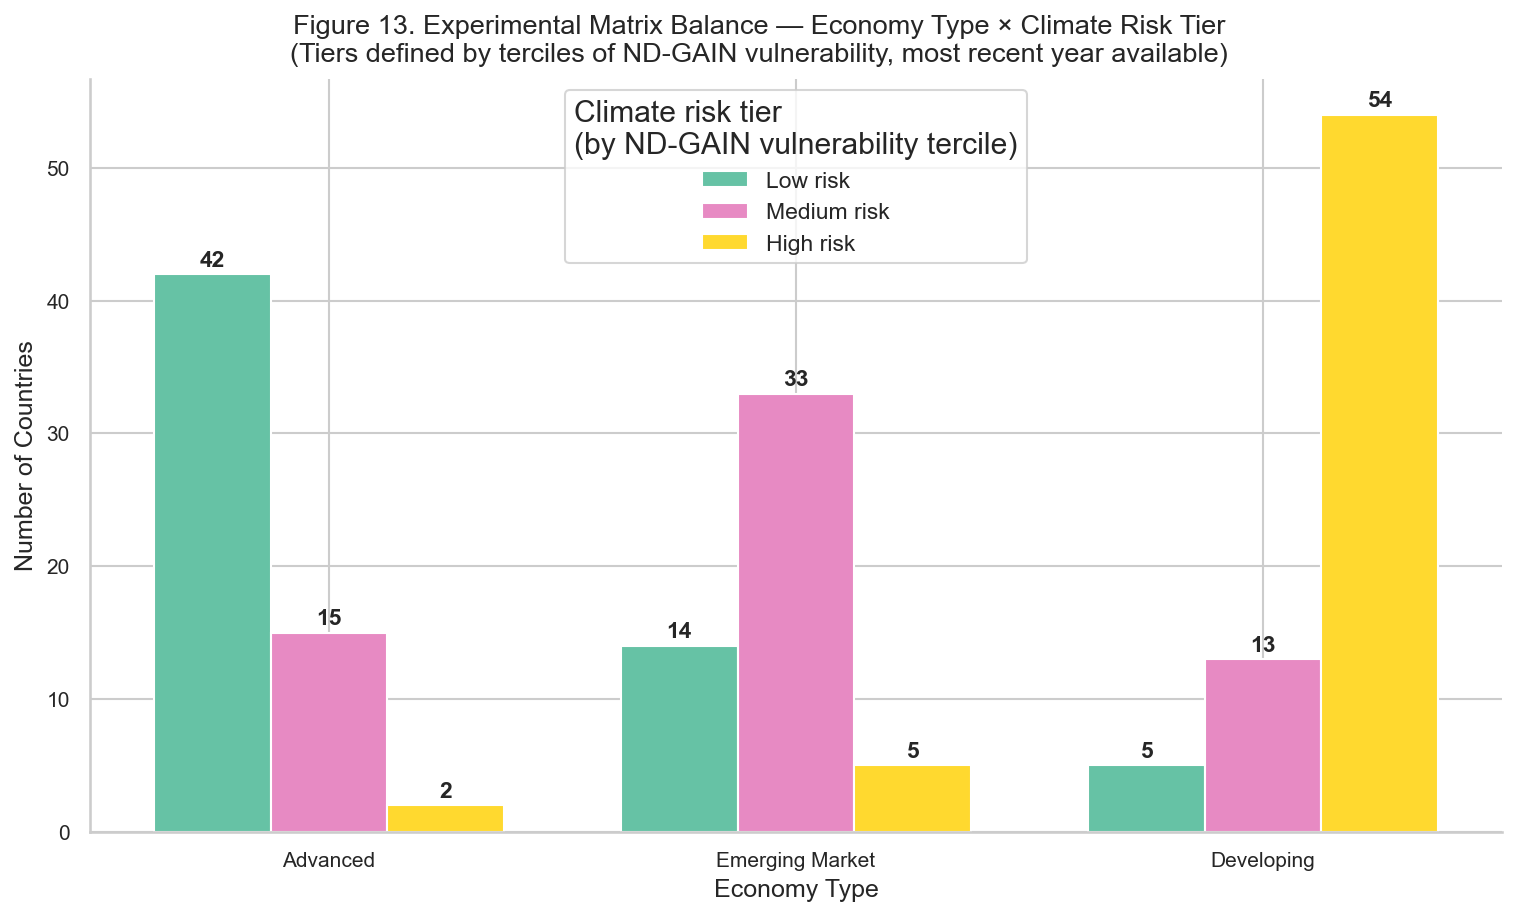

  Saved: fig_13_experimental_matrix_balance.png  |  fig_13_experimental_matrix_balance.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [19]:
try:
    # Get most recent vulnerability score per country
    recent_vuln = (
        df_analysis
        .dropna(subset=["ndgain_vulnerability", "economy_type"])
        .sort_values("year")
        .groupby("iso3")
        .last()[["ndgain_vulnerability", "economy_type", "year"]]
        .reset_index()
    )
    print(f"Countries with vulnerability score: {len(recent_vuln)}")
    print(f"Most recent year distribution: {recent_vuln['year'].value_counts().head().to_dict()}")

    # Assign climate risk tier via terciles
    tertile_edges = recent_vuln["ndgain_vulnerability"].quantile([0, 1/3, 2/3, 1]).values
    print(f"\nTercile edges: {tertile_edges.round(4)}")

    recent_vuln["climate_risk_tier"] = pd.cut(
        recent_vuln["ndgain_vulnerability"],
        bins=tertile_edges,
        labels=["Low", "Medium", "High"],
        include_lowest=True,
    )

    matrix = (
        recent_vuln
        .groupby(["economy_type", "climate_risk_tier"], observed=True)
        .size()
        .reset_index(name="n_countries")
    )
    print("\n3×3 Experimental Matrix (country counts):")
    print(matrix.pivot(index="economy_type", columns="climate_risk_tier", values="n_countries").to_string())

    TIER_COLORS = {"Low": _set2[0], "Medium": _set2[3], "High": _set2[5]}
    tier_order  = ["Low", "Medium", "High"]

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

    x     = np.arange(len(ECON_ORDER))
    width = 0.25

    for i, tier in enumerate(tier_order):
        vals = [
            matrix.loc[
                (matrix["economy_type"] == et) & (matrix["climate_risk_tier"] == tier),
                "n_countries"
            ].sum()
            for et in ECON_ORDER
        ]
        rects = ax.bar(
            x + (i - 1) * width,
            vals,
            width,
            label=f"{tier} risk",
            color=TIER_COLORS[tier],
            edgecolor="white",
        )
        for rect, v in zip(rects, vals):
            if v > 0:
                ax.text(
                    rect.get_x() + rect.get_width() / 2,
                    rect.get_height() + 0.3,
                    str(int(v)),
                    ha="center", va="bottom", fontsize=11, fontweight="bold"
                )

    ax.set_xticks(x)
    ax.set_xticklabels(ECON_ORDER, fontsize=12)
    ax.set_xlabel("Economy Type", fontsize=12)
    ax.set_ylabel("Number of Countries", fontsize=12)
    ax.legend(title="Climate risk tier\n(by ND-GAIN vulnerability tercile)", fontsize=11)
    ax.tick_params(labelsize=10)

    fig.suptitle(
        "Figure 13. Experimental Matrix Balance — Economy Type × Climate Risk Tier\n"
        "(Tiers defined by terciles of ND-GAIN vulnerability, most recent year available)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_13_experimental_matrix_balance")
    plt.close(fig)

except Exception:
    print("Figure 13 FAILED:")
    traceback.print_exc()

---
## Figure 14 — Debt-to-GDP Source Comparison

**What it shows:** Scatter plot comparing `imf_cg_debt_to_gdp` (IMF Central Government  
Debt) on the x-axis vs. `weo_govt_gross_debt` (WEO General Government Gross Debt) on  
the y-axis, for country-years where both sources are available. A 45° reference line  
represents perfect agreement.

**Why it matters:** The WEO figure (General Government) should be systematically higher  
than the IMF figure (Central Government only) because it includes subnational governments  
and off-budget entities. Documenting this level difference and the correlation between  
sources is required methodology for using a priority cascade.

**Chapter:** Appendix / Methodology

Observations with both sources: 4,876
Spearman ρ between sources: 0.153


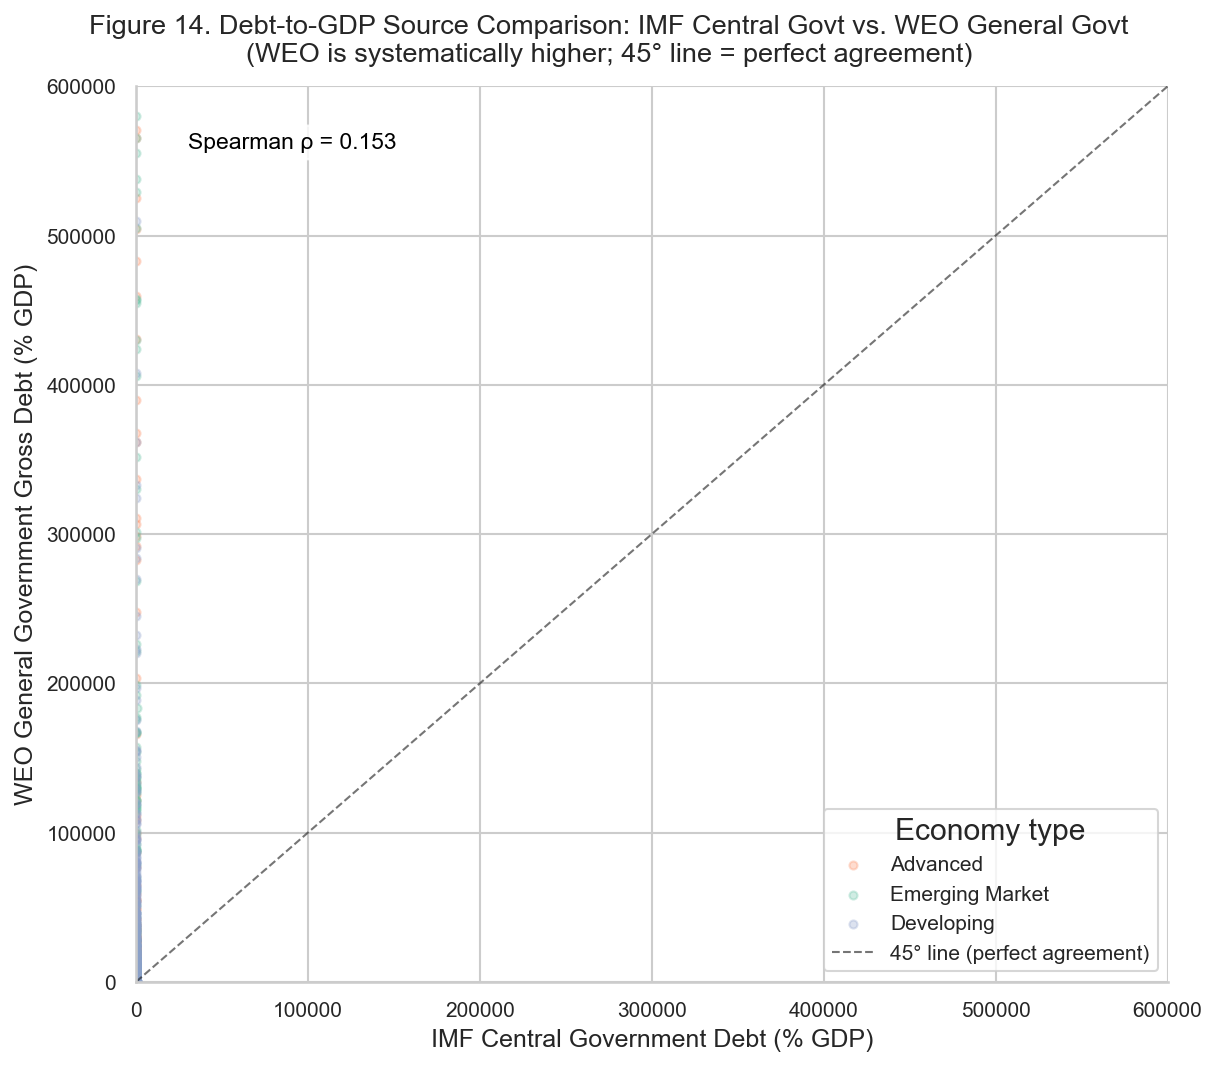

  Saved: fig_14_debt_source_comparison.png  |  fig_14_debt_source_comparison.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [20]:
try:
    df14 = df_analysis.dropna(subset=["imf_cg_debt_to_gdp", "weo_govt_gross_debt"]).copy()
    print(f"Observations with both sources: {len(df14):,}")

    # Compute Spearman correlation
    spear_r = df14[["imf_cg_debt_to_gdp", "weo_govt_gross_debt"]].corr(method="spearman").iloc[0, 1]
    print(f"Spearman ρ between sources: {spear_r:.3f}")

    cap = df14[["imf_cg_debt_to_gdp", "weo_govt_gross_debt"]].quantile(0.98).max()
    df14_plot = df14[
        (df14["imf_cg_debt_to_gdp"] <= cap) &
        (df14["weo_govt_gross_debt"] <= cap)
    ]

    fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)

    for etype in ECON_ORDER:
        sub = df14_plot[df14_plot["economy_type"] == etype]
        ax.scatter(
            sub["imf_cg_debt_to_gdp"],
            sub["weo_govt_gross_debt"],
            color=ECON_COLORS[etype],
            alpha=0.3,
            s=15,
            label=etype,
            rasterized=True,
        )

    # 45° line
    lim = [0, cap]
    ax.plot(lim, lim, "k--", linewidth=1, alpha=0.6, label="45° line (perfect agreement)")

    ax.set_xlabel("IMF Central Government Debt (% GDP)", fontsize=12)
    ax.set_ylabel("WEO General Government Gross Debt (% GDP)", fontsize=12)
    ax.legend(title="Economy type", fontsize=10)
    ax.set_xlim(0, cap)
    ax.set_ylim(0, cap)
    ax.text(0.05, 0.93, f"Spearman ρ = {spear_r:.3f}",
            transform=ax.transAxes, fontsize=11, color="black",
            bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    ax.tick_params(labelsize=10)

    fig.suptitle(
        "Figure 14. Debt-to-GDP Source Comparison: IMF Central Govt vs. WEO General Govt\n"
        "(WEO is systematically higher; 45° line = perfect agreement)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_14_debt_source_comparison")
    plt.close(fig)

except Exception:
    print("Figure 14 FAILED:")
    traceback.print_exc()

---
## Figure 15 — GDP Growth Source Comparison

**What it shows:** Scatter plot comparing GDP growth computed from WEO constant GDP  
(year-on-year % change, derived in `02_merge_master_panel.ipynb`) vs. WDI direct GDP  
growth. A 45° line indicates perfect agreement.

**Why it matters:** If the two independent sources agree closely, it validates the data  
pipeline. Large systematic divergences would indicate a methodological error (e.g.,  
wrong GDP scaling or wrong pct_change grouping) that needs to be fixed before training.

**Chapter:** Appendix / Methodology

Observations (trimmed to ±25%): 6,325
Spearman ρ: 0.947


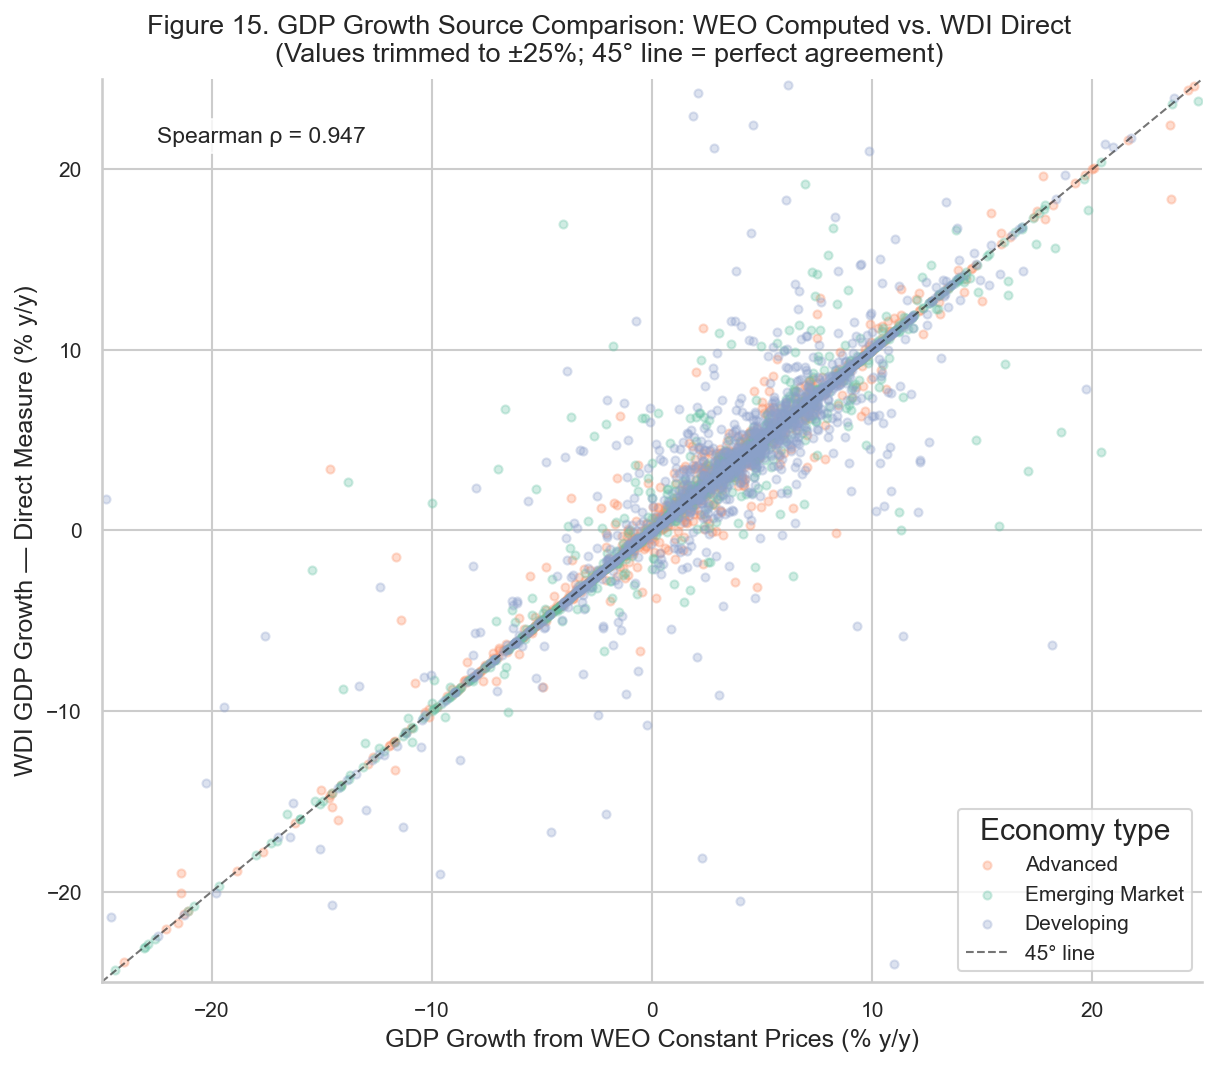

  Saved: fig_15_gdp_growth_source_comparison.png  |  fig_15_gdp_growth_source_comparison.svg  →  C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures


In [21]:
try:
    df15 = df_analysis.dropna(subset=["gdp_growth", "wdi_gdp_growth", "economy_type"]).copy()

    # Trim to ±25% for legibility (extreme crisis/hyperinflation observations)
    df15 = df15[
        (df15["gdp_growth"].between(-25, 25)) &
        (df15["wdi_gdp_growth"].between(-25, 25))
    ]
    print(f"Observations (trimmed to ±25%): {len(df15):,}")

    spear_r = df15[["gdp_growth", "wdi_gdp_growth"]].corr(method="spearman").iloc[0, 1]
    print(f"Spearman ρ: {spear_r:.3f}")

    fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)

    for etype in ECON_ORDER:
        sub = df15[df15["economy_type"] == etype]
        ax.scatter(
            sub["gdp_growth"],
            sub["wdi_gdp_growth"],
            color=ECON_COLORS[etype],
            alpha=0.3,
            s=15,
            label=etype,
            rasterized=True,
        )

    ax.plot([-25, 25], [-25, 25], "k--", linewidth=1, alpha=0.6, label="45° line")
    ax.set_xlabel("GDP Growth from WEO Constant Prices (% y/y)", fontsize=12)
    ax.set_ylabel("WDI GDP Growth — Direct Measure (% y/y)", fontsize=12)
    ax.legend(title="Economy type", fontsize=10)
    ax.set_xlim(-25, 25)
    ax.set_ylim(-25, 25)
    ax.text(0.05, 0.93, f"Spearman ρ = {spear_r:.3f}",
            transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    ax.tick_params(labelsize=10)

    fig.suptitle(
        "Figure 15. GDP Growth Source Comparison: WEO Computed vs. WDI Direct\n"
        "(Values trimmed to ±25%; 45° line = perfect agreement)",
        fontsize=13
    )

    plt.show()
    save_fig(fig, "fig_15_gdp_growth_source_comparison")
    plt.close(fig)

except Exception:
    print("Figure 15 FAILED:")
    traceback.print_exc()

---
## Table 1 — Descriptive Statistics by Economy Type

**What it shows:** For each economy type, the count, mean, standard deviation, median,  
minimum, and maximum for each key variable in the RL pipeline.

**Why it matters:** The primary summary statistics table for Chapter 3. Examiners expect  
this as the standard quantitative description of the dataset. It also surfaces any  
anomalous values that might indicate data-cleaning issues.

**Chapter:** 3 — Data Description

In [22]:
try:
    TABLE_VARS = [
        ("debt_to_gdp",              "Debt-to-GDP (%)"),
        ("gdp_growth",               "GDP Growth (% y/y)"),
        ("weo_primary_balance",      "Primary Balance (% GDP)"),
        ("inflation",                "Inflation, CPI (% y/y)"),
        ("weo_output_gap",           "Output Gap (% pot. GDP)"),
        ("ndgain_vulnerability",     "ND-GAIN Vulnerability"),
        ("ndgain_readiness",         "ND-GAIN Readiness"),
        ("climate_damage_adj_000usd","Climate Damage ('000 USD)"),
        ("climate_disaster_count",   "Disaster Count"),
    ]

    rows = []
    for col, label in TABLE_VARS:
        if col not in df_analysis.columns:
            print(f"SKIP — column not found: {col}")
            continue
        for etype in ECON_ORDER + ["All"]:
            if etype == "All":
                vals = df_analysis[col].dropna()
            else:
                vals = df_analysis.loc[
                    df_analysis["economy_type"] == etype, col
                ].dropna()
            rows.append({
                "Variable":     label,
                "Economy Type": etype,
                "N":            len(vals),
                "Mean":         vals.mean(),
                "Std":          vals.std(),
                "Median":       vals.median(),
                "Min":          vals.min(),
                "Max":          vals.max(),
            })

    stats_df = pd.DataFrame(rows)

    # Display formatted
    pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
    pd.set_option("display.max_rows", 200)
    print(stats_df.to_string(index=False))

    # Save CSV
    out_path = FIG_DIR / "table_01_descriptive_stats.csv"
    stats_df.to_csv(out_path, index=False)
    SAVED_FILES.append("table_01_descriptive_stats.csv")
    print(f"\nTable saved: {out_path}")

except Exception:
    print("Table 1 FAILED:")
    traceback.print_exc()

                 Variable    Economy Type    N               Mean                  Std   Median           Min                   Max
          Debt-to-GDP (%)        Advanced 2198             111.56             1,342.36    41.42          0.00             38,959.67
          Debt-to-GDP (%) Emerging Market 1672           1,127.40            23,700.79    40.50          0.01            939,054.36
          Debt-to-GDP (%)      Developing 2347           6,609.99           129,248.92    52.53          0.00          3,815,418.73
          Debt-to-GDP (%)             All 6329           2,792.50            79,692.65    45.27          0.00          3,815,418.73
       GDP Growth (% y/y)        Advanced 2280               2.84                 5.78     2.80        -54.34                 82.80
       GDP Growth (% y/y) Emerging Market 1762               3.40                 8.40     3.52        -50.34                147.97
       GDP Growth (% y/y)      Developing 2438               3.76           

---
## Final Summary

In [23]:
print("=" * 50)
print("=== VISUALISATION SUITE COMPLETE ===")
print("=" * 50)
print(f"Figures saved : {len(SAVED_FILES)}")
print(f"Location      : {FIG_DIR}")
print("Files:")
for f in sorted(set(SAVED_FILES)):
    p = FIG_DIR / f
    size = p.stat().st_size / 1024 if p.exists() else 0
    print(f"  {f:<55}  ({size:.0f} KB)")

=== VISUALISATION SUITE COMPLETE ===
Figures saved : 33
Location      : C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent\outputs\figures
Files:
  fig_01_country_coverage_map.png                          (918 KB)
  fig_01_country_coverage_map.svg                          (14129 KB)
  fig_02_temporal_coverage_heatmap.png                     (273 KB)
  fig_02_temporal_coverage_heatmap.svg                     (338 KB)
  fig_03_missingness_profile.png                           (330 KB)
  fig_03_missingness_profile.svg                           (89 KB)
  fig_04_sample_size_economy_decade.png                    (183 KB)
  fig_04_sample_size_economy_decade.svg                    (53 KB)
  fig_05_state_variable_distributions.png                  (538 KB)
  fig_05_state_variable_distributions.svg                  (315 KB)
  fig_06_state_variable_boxplots.png                       (348 KB)
  fig_06_state_variable_boxplots.svg                       (513 KB)
  fig_07_correlation_heatmap.